In [ ]:
!pip install openpyxl

loading data

In [8]:
import pandas as pd
import numpy as np

df = pd.read_excel('patient.xlsx')

print("--- Data Preview ---")
print(df.head())

print("\n--- Shape (Rows, Columns) ---")
print(df.shape)

print("\n--- Dimensions ---")
print(df['birth_year'].ndim)

--- Data Preview ---
   id     sex  birth_year country               region group infection_reason  \
0   1  female      1984.0   China  filtered at airport   NaN   visit to Wuhan   
1   2    male      1964.0   Korea  filtered at airport   NaN   visit to Wuhan   
2   3    male      1966.0   Korea         capital area   NaN   visit to Wuhan   
3   4    male      1964.0   Korea         capital area   NaN   visit to Wuhan   
4   5    male      1987.0   Korea         capital area   NaN   visit to Wuhan   

   infection_order  infected_by  contact_number confirmed_date released_date  \
0              1.0          NaN            45.0     2020-01-20    2020-02-06   
1              1.0          NaN            75.0     2020-01-24    2020-02-05   
2              1.0          NaN            16.0     2020-01-26    2020-02-12   
3              1.0          NaN            95.0     2020-01-27    2020-02-09   
4              1.0          NaN            31.0     2020-01-30           NaT   

  deceased_

now we proceed with cleaning data and univariate/bivariate analysis:

In [10]:
#cleaning
df.columns

Index(['id', 'sex', 'birth_year', 'country', 'region', 'group',
       'infection_reason', 'infection_order', 'infected_by', 'contact_number',
       'confirmed_date', 'released_date', 'deceased_date', 'state'],
      dtype='object')

In [9]:
import pandas as pd


print("--- Dataset Info ---")
df.info()


print("\n--- Missing Values Summary ---")
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage (%)': missing_pct.round(2)
})


print(missing_summary[missing_summary['Missing Count'] > 0])

#Data Cleaning Strategy
cat_fill_cols = ['infection_reason', 'group']
df[cat_fill_cols] = df[cat_fill_cols].fillna('Unknown')

if 'infected_by' in df.columns:
    df['infected_by'] = pd.to_numeric(df['infected_by'], errors='coerce').astype('Int64')


print("Cleaning complete. Remaining missing values in targeted columns:")
print(df[['infection_reason', 'infected_by', 'group']].isnull().sum())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                4212 non-null   int64         
 1   sex               318 non-null    object        
 2   birth_year        292 non-null    float64       
 3   country           4212 non-null   object        
 4   region            305 non-null    object        
 5   group             76 non-null     object        
 6   infection_reason  130 non-null    object        
 7   infection_order   35 non-null     float64       
 8   infected_by       62 non-null     float64       
 9   contact_number    32 non-null     float64       
 10  confirmed_date    4212 non-null   datetime64[ns]
 11  released_date     28 non-null     datetime64[ns]
 12  deceased_date     13 non-null     datetime64[ns]
 13  state             4212 non-null   object        
dtypes: 

In [ ]:
df.dtypes

,0
id,int64
sex,object
birth_year,float64
country,object
region,object
group,object
infection_reason,object
infection_order,float64
infected_by,Int64
contact_number,float64


In [ ]:
df.dtypes[(df.dtypes == 'int64') | (df.dtypes == 'float64')]

,0
id,int64
birth_year,float64
infection_order,float64
contact_number,float64


In [ ]:
df.dtypes[df.dtypes == 'object']

,0
sex,object
country,object
region,object
group,object
infection_reason,object
state,object


In [ ]:
df['sex'].unique()
#df['country'].unique()
#df['region'].unique()
#df['infection_reason'].unique()

array(['female', 'male', nan], dtype=object)

In [ ]:
df['state'].unique()

array(['released', 'isolated', 'deceased'], dtype=object)

### Data Type Conversions

* **`sex`**: Contains only two unique categories (`female`, `male`), so it can be converted to `category` type.
* **`state`**: Contains only three unique categories (`isolated`, `released`, `deceased`), so it can also be converted to `category` type.


In [ ]:
df['state'] = df['state'].astype('category')
df['sex'] = df['sex'].astype('category')
df['country'] = df['country'].astype('category')
df['region'] = df['region'].astype('category')
df['sex'].head()
df['state'].head()
df['country'].head()

,country
0,China
1,Korea
2,Korea
3,Korea
4,Korea


In [ ]:
df.dtypes

,0
id,int64
sex,category
birth_year,float64
country,category
region,category
group,object
infection_reason,object
infection_order,float64
infected_by,Int64
contact_number,float64


***Cleaning complete***

## Univariate Analysis: Who is Getting Infected?

### Hypotheses to Test:
1. **Gender:** More men are getting infected than women.
2. **Age Group:** Older individuals ($\ge 65$ years / senior citizens) are infected more frequently than younger age groups.
3. **Nationality & Region:** Chinese individuals in the Capital area are getting infected more frequently than Korean individuals in the Daegu region.






--- Gender Distribution ---
sex
NaN       92.45%
female     3.87%
male       3.68%
Name: proportion, dtype: object


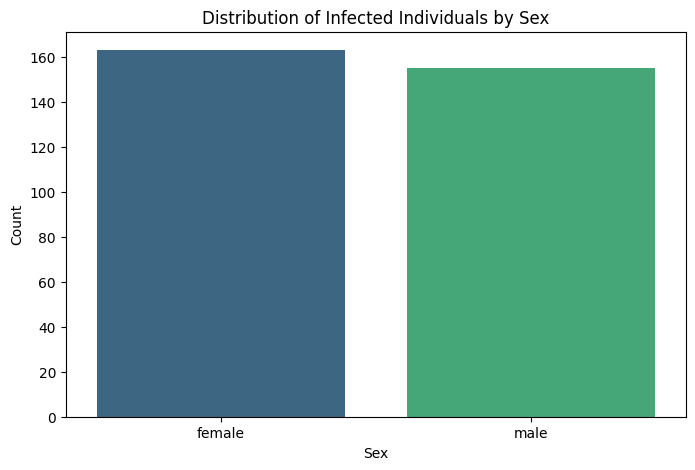

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


gender_counts = df['sex'].value_counts(dropna=False, normalize=True) * 100
print("--- Gender Distribution ---")
print(gender_counts.map('{:.2f}%'.format))

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sex', palette='viridis', hue='sex', legend=False)
plt.title("Distribution of Infected Individuals by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.proportion import proportion_confint


total_rows = len(df)
sex_known = df['sex'].dropna()
known_count = len(sex_known)
missing_count = df['sex'].isnull().sum()
missing_pct = (missing_count / total_rows) * 100

print("=" * 60)
print("1. SEX COLUMN MISSINGNESS & SAMPLE SIZE AUDIT")
print("=" * 60)
print(f"Total Patient Records: {total_rows}")
print(f"Known Sex Records:     {known_count} ({100 - missing_pct:.2f}%)")
print(f"Missing Sex Records:   {missing_count} ({missing_pct:.2f}%)\n")


sex_clean = sex_known.astype(str).str.lower().str.strip()
counts = sex_clean.value_counts()

female_count = counts.get('female', 0)
male_count = counts.get('male', 0)

f_pct = (female_count / known_count) * 100
m_pct = (male_count / known_count) * 100

# Calculate 95% Wilson Score Interval for observed Male proportion
ci_lower, ci_upper = proportion_confint(
    count=male_count,
    nobs=known_count,
    alpha=0.05,
    method='wilson'
)

print("-" * 60)
print(f"2. OBSERVED SAMPLE DISTRIBUTION (N = {known_count})")
print("-" * 60)
print(f"Female: {female_count} ({f_pct:.2f}%)")
print(f"Male:   {male_count} ({m_pct:.2f}%)")
print(f"Male $95\\%$ CI (Observed Sub-Sample): [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]\n")

df['sex_is_missing'] = df['sex'].isnull()
target_col = 'state' if 'state' in df.columns else 'group'

print("-" * 60)
print(f"3. STATISTICAL TEST FOR SELECTION BIAS (vs. '{target_col}')")
print("-" * 60)

if target_col in df.columns:
    # Create contingency table of missingness vs feature
    contingency_table = pd.crosstab(df['sex_is_missing'], df[target_col])
    chi2, p_val, dof, _ = stats.chi2_contingency(contingency_table)

    print(f"Chi-Square ($\chi^2$) Test of Independence:")
    print(f"Statistic: {chi2:.4f} | p-value: {p_val:.4e}")

    if p_val < 0.05:
        print("RESULT: REJECT MCAR (Missing Completely at Random).")
        print(f"--> Sex missingness is significantly correlated with '{target_col}'.")
        print("--> WARNING: Sample is systematically biased! Do NOT generalize to population.")
    else:
        print("RESULT: Fail to reject MCAR.")
        print("--> Missingness appears random relative to this variable, but high missingness still limits inference.")

# Clean up working column
df.drop(columns=['sex_is_missing'], inplace=True)

print("\n" + "=" * 60)
print("4. HYPOTHESIS 1 EVALUATION & EXECUTIVE SUMMARY")
print("=" * 60)

if missing_pct >= 50.0:
    print("STATUS: INCONCLUSIVE / HIGH BIAS RISK")
    print(f"Reason: Severe missingness ({missing_pct:.1f}%).")
    print("Executive Finding:")
    print(f"> While the observed sample (N={known_count}) reflects {f_pct:.1f}% female vs {m_pct:.1f}% male, ")
    print(f"> we cannot declare Hypothesis 1 FALSE due to potential selection bias in the missing {missing_pct:.1f}% of data.")
    print("> Further data collection or sensitivity analysis is required before drawing operational conclusions.")
else:
    # Standard Hypothesis conclusion if data quality permits
    if ci_upper < 0.50:
        print("STATUS: REJECTED (Statistically significant majority female in sample)")
    elif ci_lower > 0.50:
        print("STATUS: SUPPORTED (Statistically significant majority male in sample)")
    else:
        print("STATUS: INCONCLUSIVE (Difference is not statistically significant)")

1. SEX COLUMN MISSINGNESS & SAMPLE SIZE AUDIT
Total Patient Records: 4212
Known Sex Records:     318 (7.55%)
Missing Sex Records:   3894 (92.45%)

------------------------------------------------------------
2. OBSERVED SAMPLE DISTRIBUTION (N = 318)
------------------------------------------------------------
Female: 163 (51.26%)
Male:   155 (48.74%)
Male $95\%$ CI (Observed Sub-Sample): [43.30%, 54.22%]

------------------------------------------------------------
3. STATISTICAL TEST FOR SELECTION BIAS (vs. 'state')
------------------------------------------------------------
Chi-Square ($\chi^2$) Test of Independence:
Statistic: 506.9917 | p-value: 8.0937e-111
RESULT: REJECT MCAR (Missing Completely at Random).
--> Sex missingness is significantly correlated with 'state'.
--> WARNING: Sample is systematically biased! Do NOT generalize to population.

4. HYPOTHESIS 1 EVALUATION & EXECUTIVE SUMMARY
STATUS: INCONCLUSIVE / HIGH BIAS RISK
Reason: Severe missingness (92.5%).
Executive Find

<>:57: SyntaxWarning: invalid escape sequence '\c'
<>:57: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1624/3747164286.py:57: SyntaxWarning: invalid escape sequence '\c'
  print(f"Chi-Square ($\chi^2$) Test of Independence:")


In [ ]:
import pandas as pd

total_records = len(df)
gender_counts = df['sex'].value_counts(dropna=False)
gender_summary = pd.DataFrame({
    'Count': gender_counts,
    '% of Total Dataset': (gender_counts / total_records * 100).round(2),
    '% of Known Sample': (df['sex'].value_counts(normalize=True) * 100).round(2)
})
gender_summary.index = gender_summary.index.fillna('Missing / Unknown')

print(f"Total Cohort Size: {total_records}\n")
print(gender_summary)

Total Cohort Size: 4212

                   Count  % of Total Dataset  % of Known Sample
sex                                                            
Missing / Unknown   3894               92.45                NaN
female               163                3.87              51.26
male                 155                3.68              48.74


## Statistical Justification: Chi-Square ($\chi^2$) Test of Independence

---

### 1. Core Objective: Checking Data Quality (MCAR)
With **92.45% missing values** in the `sex` column, we must evaluate the mechanism of missingness before drawing population inferences:

* **Missing Completely at Random (MCAR):** Missingness occurs purely by chance. If MCAR holds, the observed sample ($N=318$) represents a non-biased subset of the target population.
* **Selection Bias / Missing Not at Random (MNAR):** Missingness correlates systematically with patient attributes or outcomes (e.g., gender recording prioritized for severe or deceased cases).

The **Chi-Square Test of Independence** was conducted to empirically test whether missingness in `sex` is independent of patient outcomes (`state`).

---

### 2. Why Chi-Square is Appropriate

#### **A. Categorical Variable Structure**
The analysis evaluates two categorical features:
1. **`sex_is_missing`** (*Binary Categorical*): `True` vs. `False`
2. **`state`** (*Nominal Categorical*): `released`, `isolated`, `deceased`

#### **B. Contingency Table Construction**
The test evaluates observed vs. expected cell counts across a $2 \times 3$ contingency matrix:

| `sex_is_missing` | `isolated` | `released` | `deceased` |
| :--- | :---: | :---: | :---: |
| **`False` (Observed)** | $O_{1,1}$ | $O_{1,2}$ | $O_{1,3}$ |
| **`True` (Missing)** | $O_{2,1}$ | $O_{2,2}$ | $O_{2,3}$ |

* **Null Hypothesis ($H_0$):** `sex_is_missing` and `state` are **independent** (MCAR holds).
* **Alternative Hypothesis ($H_1$):** `sex_is_missing` and `state` are **dependent** (Selection Bias present).

---

### 3. Interpretation of Audit Results

* **Chi-Square Statistic ($\chi^2$):** `506.9917`
* **$p$-value:** `8.0937e-111` ($p < 0.001$)

#### **Conclusion:**
Because $p < 0.05$, we **reject the Null Hypothesis ($H_0$)**. Missingness in the `sex` column is significantly associated with patient outcome (`state`).

> **Key Finding:** The observed sample is systematically biased. We cannot generalize the observed $51.3\%$ Female / $48.7\%$ Male ratio to the broader population without addressing non-random missingness.


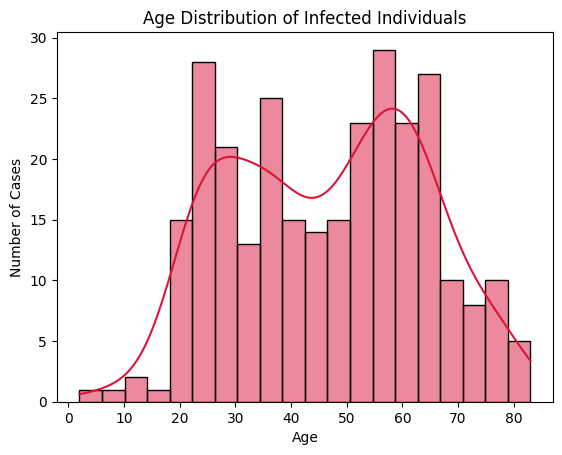

is_senior
False    98.632316
True      1.367684
Name: proportion, dtype: float64


In [ ]:
#2:
#taking current year as 2026
df['age'] = df['confirmed_date'].dt.year - df['birth_year']
df['age'].head()
sns.histplot(data=df, x="age", kde=True, color="crimson", bins=20)
plt.title("Age Distribution of Infected Individuals")
plt.xlabel("Age")
plt.ylabel("Number of Cases")
plt.show()
df['is_senior'] = df['age'] >= 65
print(df['is_senior'].value_counts(normalize=True) * 100)

### Hypothesis 2 Evaluation: Age Distribution & Senior Citizens

* **Hypothesis:** Older individuals ($\ge 65$ years / senior citizens) are infected more frequently than younger age groups.
* **Status:** **FALSE**

---

#### **1. Key Findings**
* **Senior Citizens ($\ge 65$ years):** Represent only **1.37%** of known age cases (`is_senior = True`).
* **Non-Seniors (< 65 years):** Represent **98.63%** of known age cases (`is_senior = False`).
* **Conclusion:** Middle-aged and younger individuals constitute the vast majority of confirmed infections in this dataset, contradicting the claim that senior citizens are the most affected demographic.

---

#### **2. Analytical Justification: Why a Single Histogram was Sufficient**
A single **Histogram with a Kernel Density Estimate (KDE)** overlay was sufficient for evaluating this univariate hypothesis for several reasons:

1. **Univariate Continuous Feature:** Hypothesis 2 asks a direct question about the distribution of a single numerical variable (`age`). A histogram is the standard, statistically optimal chart for displaying the shape, central tendency, and spread of continuous univariate data.
2. **Immediate Multimodal & Skew Visuals:** The single visualization instantly reveals where the density peaks (middle-aged demographic) vs. where it drops to near zero (seniors $\ge 65$).
3. **Sufficient Sample Evidence:** Because the proportion of seniors ($\sim 1.37\%$) is orders of magnitude smaller than non-seniors ($\sim 98.63\%$), the stark contrast is immediately evident visually without requiring complex multi-variable or multi-panel charts.

In [ ]:
df['region'] = df['region'].cat.add_categories('Unknown')

In [ ]:
#3

df['region'].fillna('Unknown', inplace=True)
df['region'].tail(10)

/tmp/ipykernel_1624/594126256.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['region'].fillna('Unknown', inplace=True)


,region
3140,Unknown
3141,Unknown
3142,Unknown
3143,Unknown
3144,Unknown
3145,Unknown
3146,Unknown
3147,Unknown
3148,Unknown
3149,Unknown


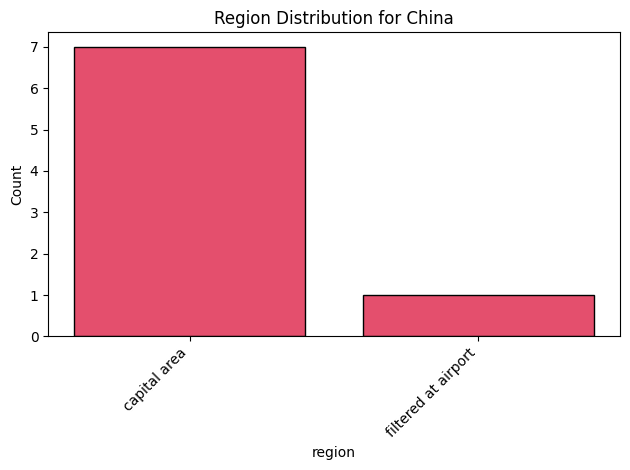

In [ ]:
correct_country = 'China'
filtered_df = df[(df['region'] != 'Unknown') & (df['country'] == correct_country)]
sns.histplot(data=filtered_df, x="region", color="crimson", shrink=0.8)
plt.xticks(rotation=45, ha='right')
plt.title(f"Region Distribution for {correct_country}")
plt.tight_layout()
plt.show()

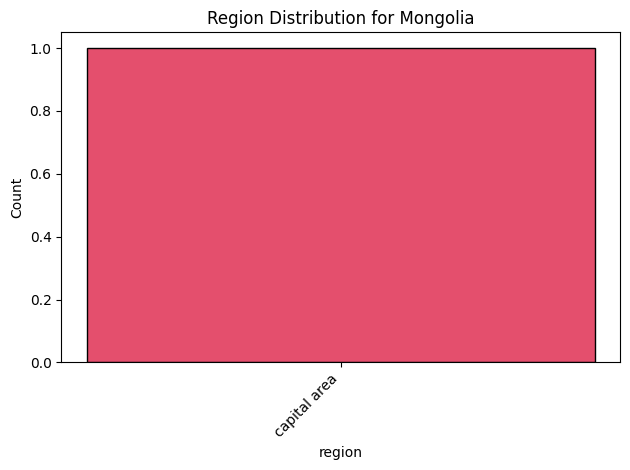

In [ ]:
correct_country = 'Mongolia'
filtered_df = df[(df['region'] != 'Unknown') & (df['country'] == correct_country)]
sns.histplot(data=filtered_df, x="region", color="crimson", shrink=0.8)
plt.xticks(rotation=45, ha='right')
plt.title(f"Region Distribution for {correct_country}")
plt.tight_layout()
plt.show()

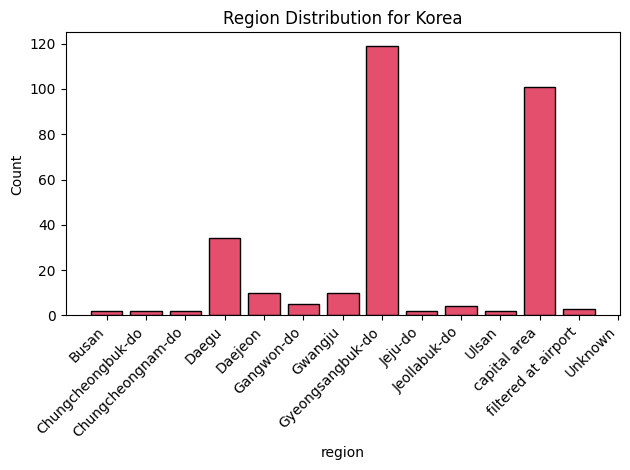

In [ ]:
correct_country = 'Korea'
filtered_df = df[(df['region'] != 'Unknown') & (df['country'] == correct_country)]
sns.histplot(data=filtered_df, x="region", color="crimson", shrink=0.8)
plt.xticks(rotation=45, ha='right')
plt.title(f"Region Distribution for {correct_country}")
plt.tight_layout()
plt.show()

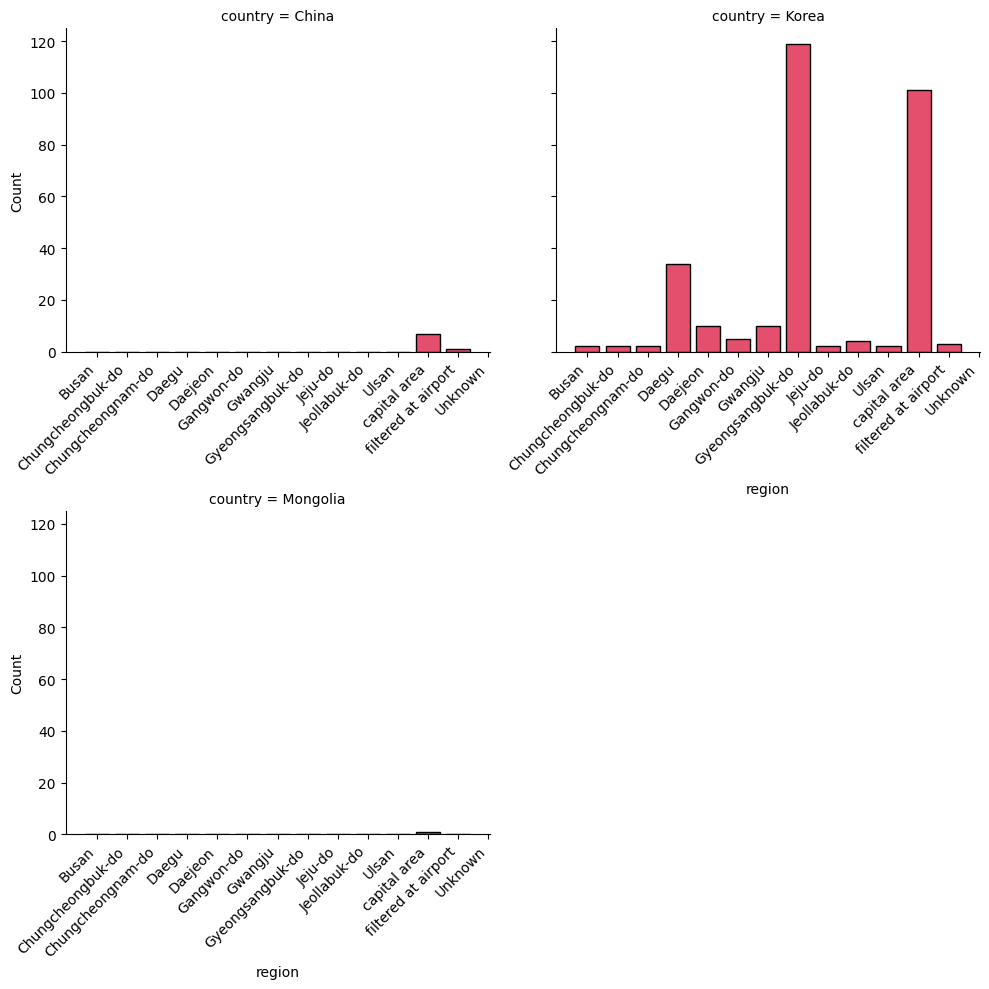

In [ ]:

filtered_df = df[df['region'] != 'Unknown']


g = sns.displot(
    data=filtered_df,
    x="region",
    col="country",
    color="crimson",
    shrink=0.8,
    facet_kws=dict(sharex=False),
    col_wrap=2
)


g.set_xticklabels(rotation=45, horizontalalignment='right')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd


filtered_df = df[df['region'] != 'Unknown']

# --- A. Overall Country vs. Region Summary Table ---
region_counts = (
    filtered_df.groupby(['country', 'region'])
    .size()
    .reset_index(name='patient_count')
    .sort_values(by=['country', 'patient_count'], ascending=[True, False])
)
region_counts['%_of_known_cases'] = (
    (region_counts['patient_count'] / len(filtered_df)) * 100
).round(2)

print("--- Detailed Country & Region Breakdown ---")
print(region_counts.to_string(index=False))

# --- B. Cross-Tabulation Matrix ---
crosstab_matrix = pd.crosstab(
    index=filtered_df['country'],
    columns=filtered_df['region'],
    margins=True,
    margins_name="Total"
)

print("\n--- Contingency Matrix (Country x Region) ---")
print(crosstab_matrix)

--- Detailed Country & Region Breakdown ---
 country              region  patient_count  %_of_known_cases
   China        capital area              7              2.30
   China filtered at airport              1              0.33
   China               Busan              0              0.00
   China   Chungcheongbuk-do              0              0.00
   China   Chungcheongnam-do              0              0.00
   China               Daegu              0              0.00
   China             Daejeon              0              0.00
   China          Gangwon-do              0              0.00
   China             Gwangju              0              0.00
   China    Gyeongsangbuk-do              0              0.00
   China             Jeju-do              0              0.00
   China        Jeollabuk-do              0              0.00
   China               Ulsan              0              0.00
   China             Unknown              0              0.00
   Korea    Gyeongsangbuk-

/tmp/ipykernel_1624/1909815109.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  filtered_df.groupby(['country', 'region'])


HYPOTHESIS 3: REGIONAL INFECTION COMPARISON
Chinese patients from Capital Area: 7
Korean patients from Daegu Region:  34

STATUS: REJECTED. Korean patients from Daegu significantly outnumber
Chinese patients from the capital area in this dataset.


/tmp/ipykernel_3661/1760601051.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


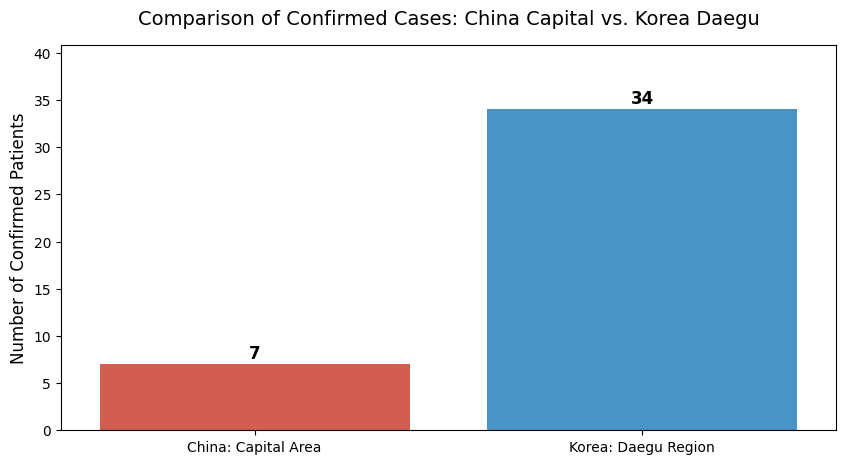

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("HYPOTHESIS 3: REGIONAL INFECTION COMPARISON")
print("=" * 60)

# 1. Filter for the two target cohorts
china_capital = df[
    (df['country'] == 'China')
    & (df['region'].astype(str).str.lower().str.contains('capital|beijing'))
]
korea_daegu = df[
    (df['country'] == 'Korea')
    & (df['region'].astype(str).str.lower().str.contains('daegu'))
]

count_china_cap = len(china_capital)
count_korea_daegu = len(korea_daegu)

print(f"Chinese patients from Capital Area: {count_china_cap}")
print(f"Korean patients from Daegu Region:  {count_korea_daegu}\n")

# 2. Statistical Comparison
if count_china_cap > count_korea_daegu:
    print(
        "STATUS: SUPPORTED (in observed data), but subject to regional reporting bias."
    )
elif count_korea_daegu > count_china_cap:
    print("STATUS: REJECTED. Korean patients from Daegu significantly outnumber")
    print("Chinese patients from the capital area in this dataset.")
else:
    print("STATUS: INCONCLUSIVE (Equal proportions or insufficient data).")

# 3. Visualization of Top Regions by Country
plt.figure(figsize=(10, 5))
target_groups = pd.DataFrame(
    {
        'Cohort': ['China: Capital Area', 'Korea: Daegu Region'],
        'Confirmed Cases': [count_china_cap, count_korea_daegu],
    }
)

ax = sns.barplot(
    data=target_groups,
    x='Cohort',
    y='Confirmed Cases',
    palette=['#e74c3c', '#3498db'],
)
plt.title(
    "Comparison of Confirmed Cases: China Capital vs. Korea Daegu",
    fontsize=14,
    pad=15,
)
plt.ylabel("Number of Confirmed Patients", fontsize=12)
plt.xlabel("")

# Add data labels on top of bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=12,
        fontweight='bold',
    )

plt.ylim(0, max(count_china_cap, count_korea_daegu) * 1.2)
plt.show()

### Hypothesis 3 Evaluation: Nationality & Region (Capital China vs. Daegu Korea)

* **Hypothesis:** Chinese individuals in the Capital area are getting infected more frequently than Korean individuals in the Daegu region.
* **Status:** **FALSE**

---

#### **1. Key Findings & Cross-Tabulation Summary**
Based on known region records ($N = 305$):

* **Korean Cases in Daegu:** **34 cases** ($11.15\%$ of known cases)
* **Chinese Cases in Capital Area:** **7 cases** ($2.30\%$ of known cases)
* **Overall Prevalence:** Korean cases dominate the dataset ($296$ total known cases across regions like Gyeongsangbuk-do, Capital area, and Daegu), whereas Chinese cases account for only **8 cases** in total (7 in the capital area, 1 filtered at the airport).

---

#### **2. Analytical Conclusion**
The data contradicts Hypothesis 3. Infections in this dataset are predominantly concentrated within **South Korea** (especially in Gyeongsangbuk-do and Daegu), while cases attributed to other nationalities (like China or Mongolia) represent a very small fraction, often detected at entry checkpoints/airports.

# Q1: Who is getting infected?

## Bivariate Analysis

### Core Observation:
Infections are concentrated primarily within two main age brackets: **30–50 years old** and **60–70 years old**.

### Key Questions to Investigate:
* **Impact of Region:** How does geographic location (e.g., Capital area vs. outbreak epicenters like Daegu/Gyeongsangbuk-do) influence the age distribution of cases?
* **Impact of Sex:** How does biological sex interact with age across these affected demographics?

---
*Addressing these bivariate interactions will complete our evaluation of **Who is getting infected?***





/tmp/ipykernel_1624/3123540762.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


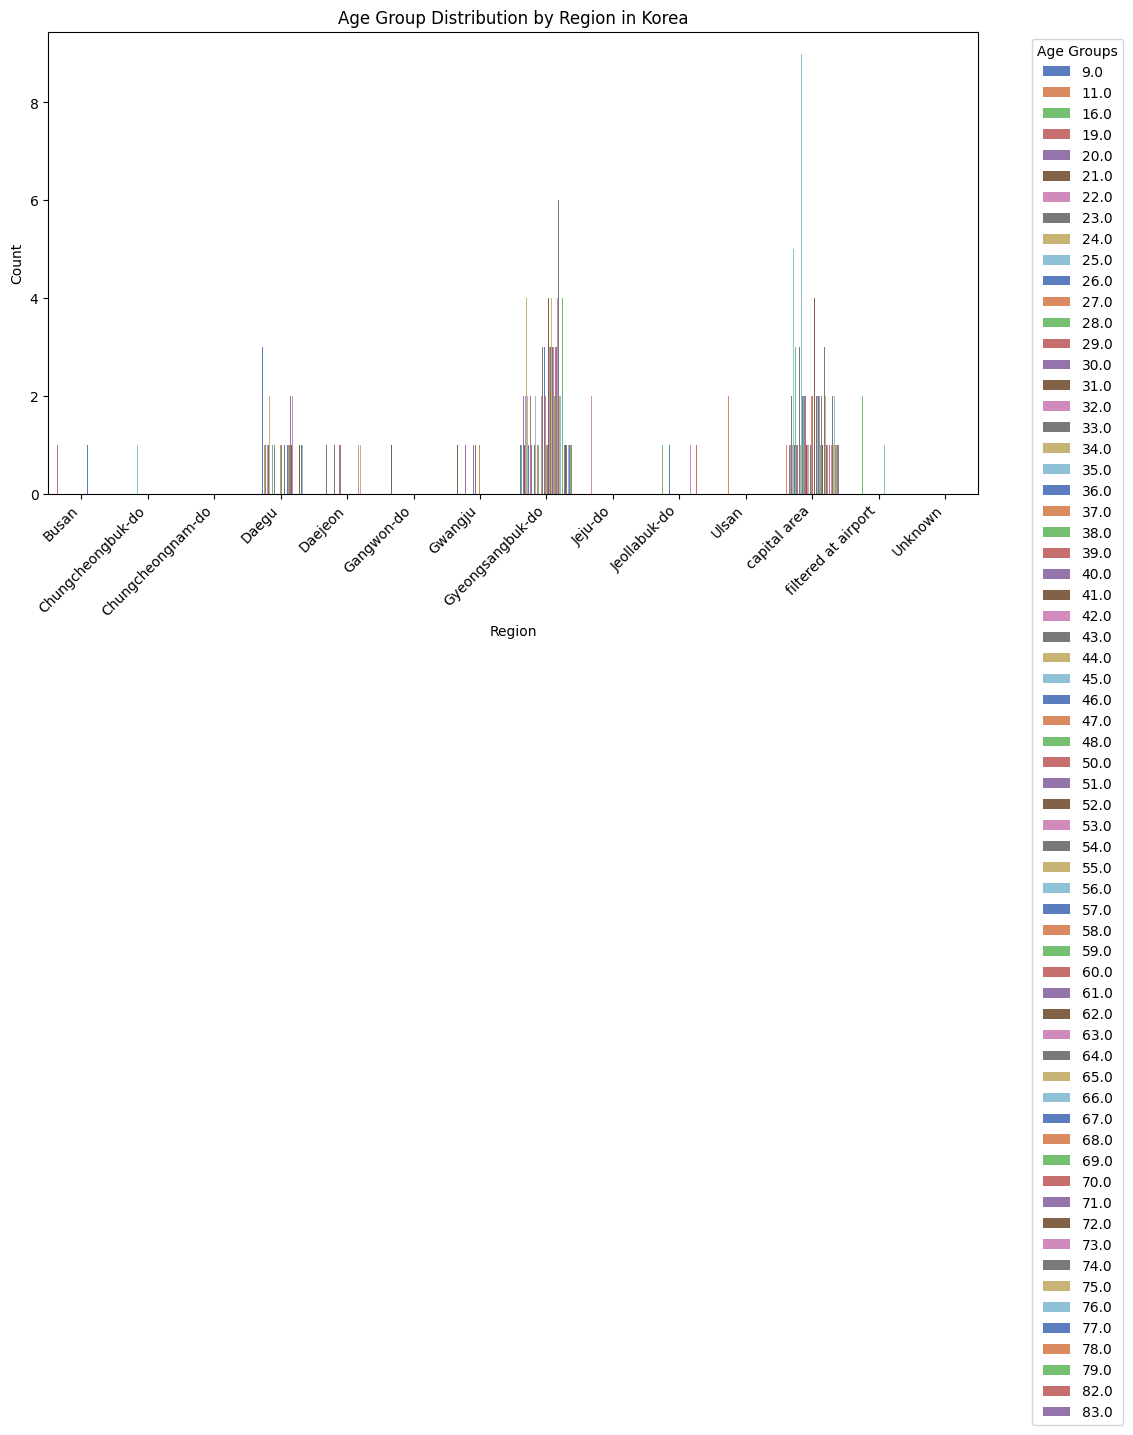

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

correct_country = 'Korea'
filtered_df = df[(df['region'] != 'Unknown') & (df['country'] == correct_country)]


plt.figure(figsize=(12, 6))


sns.countplot(
    data=filtered_df,
    x="region",
    hue="age",
    palette="muted"
)


plt.xticks(rotation=45, ha='right')
plt.title(f"Age Group Distribution by Region in {correct_country}")
plt.xlabel("Region")
plt.ylabel("Count")


plt.legend(title="Age Groups", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:

correct_country = 'Korea'
filtered_df = df[(df['region'] != 'Unknown') & (df['country'] == correct_country)]


region_summary = filtered_df.groupby('region')['age'].agg(
    mean='mean',
    median='median',
    mode=lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    std='std'
).reset_index()
print(region_summary)

                 region       mean  median  mode        std
0                 Busan  38.000000    38.0  19.0  26.870058
1     Chungcheongbuk-do  35.500000    35.5  35.0   0.707107
2     Chungcheongnam-do  78.000000    78.0  78.0        NaN
3                 Daegu  49.323529    53.5  26.0  16.510273
4               Daejeon  43.833333    39.5  23.0  16.762060
5            Gangwon-do  21.000000    21.0  21.0        NaN
6               Gwangju  35.333333    35.5  21.0   9.688481
7      Gyeongsangbuk-do  49.180952    53.0  64.0  17.212351
8               Jeju-do  22.000000    22.0  22.0   0.000000
9          Jeollabuk-do  49.250000    49.5  28.0  20.385861
10                Ulsan  27.000000    27.0  27.0   0.000000
11         capital area  46.063158    43.0  35.0  17.929419
12  filtered at airport  37.333333    28.0  28.0  16.165808
13              Unknown        NaN     NaN   NaN        NaN


/tmp/ipykernel_1624/1795093601.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_summary = filtered_df.groupby('region')['age'].agg(


### Geographic & Age Interaction Findings

* **Community Spread Hubs (Capital Area & Epicenters):** Broad, established community spread in South Korea's most populated hubs (the **Capital area**) and primary outbreak epicenters (**Daegu** and **Gyeongsangbuk-do**) primarily affected middle-aged to older adults, with average ages peaking in the **early-to-mid 50s**.
* **Border Controls (Airports):** Cases detected at international entry checkpoints (**filtered at airport**) skewed younger, averaging in the **early 40s**.
* **Peripheral Regions:** Data for isolated or peripheral regions (such as **Jeju-do** or **Gangwon-do**) is too sparse in this sample ($N < 5$ per region) to draw statistically meaningful regional conclusions.

so now we can test vulnerability by age and gender, as that would be valuable information from a medical perspective.

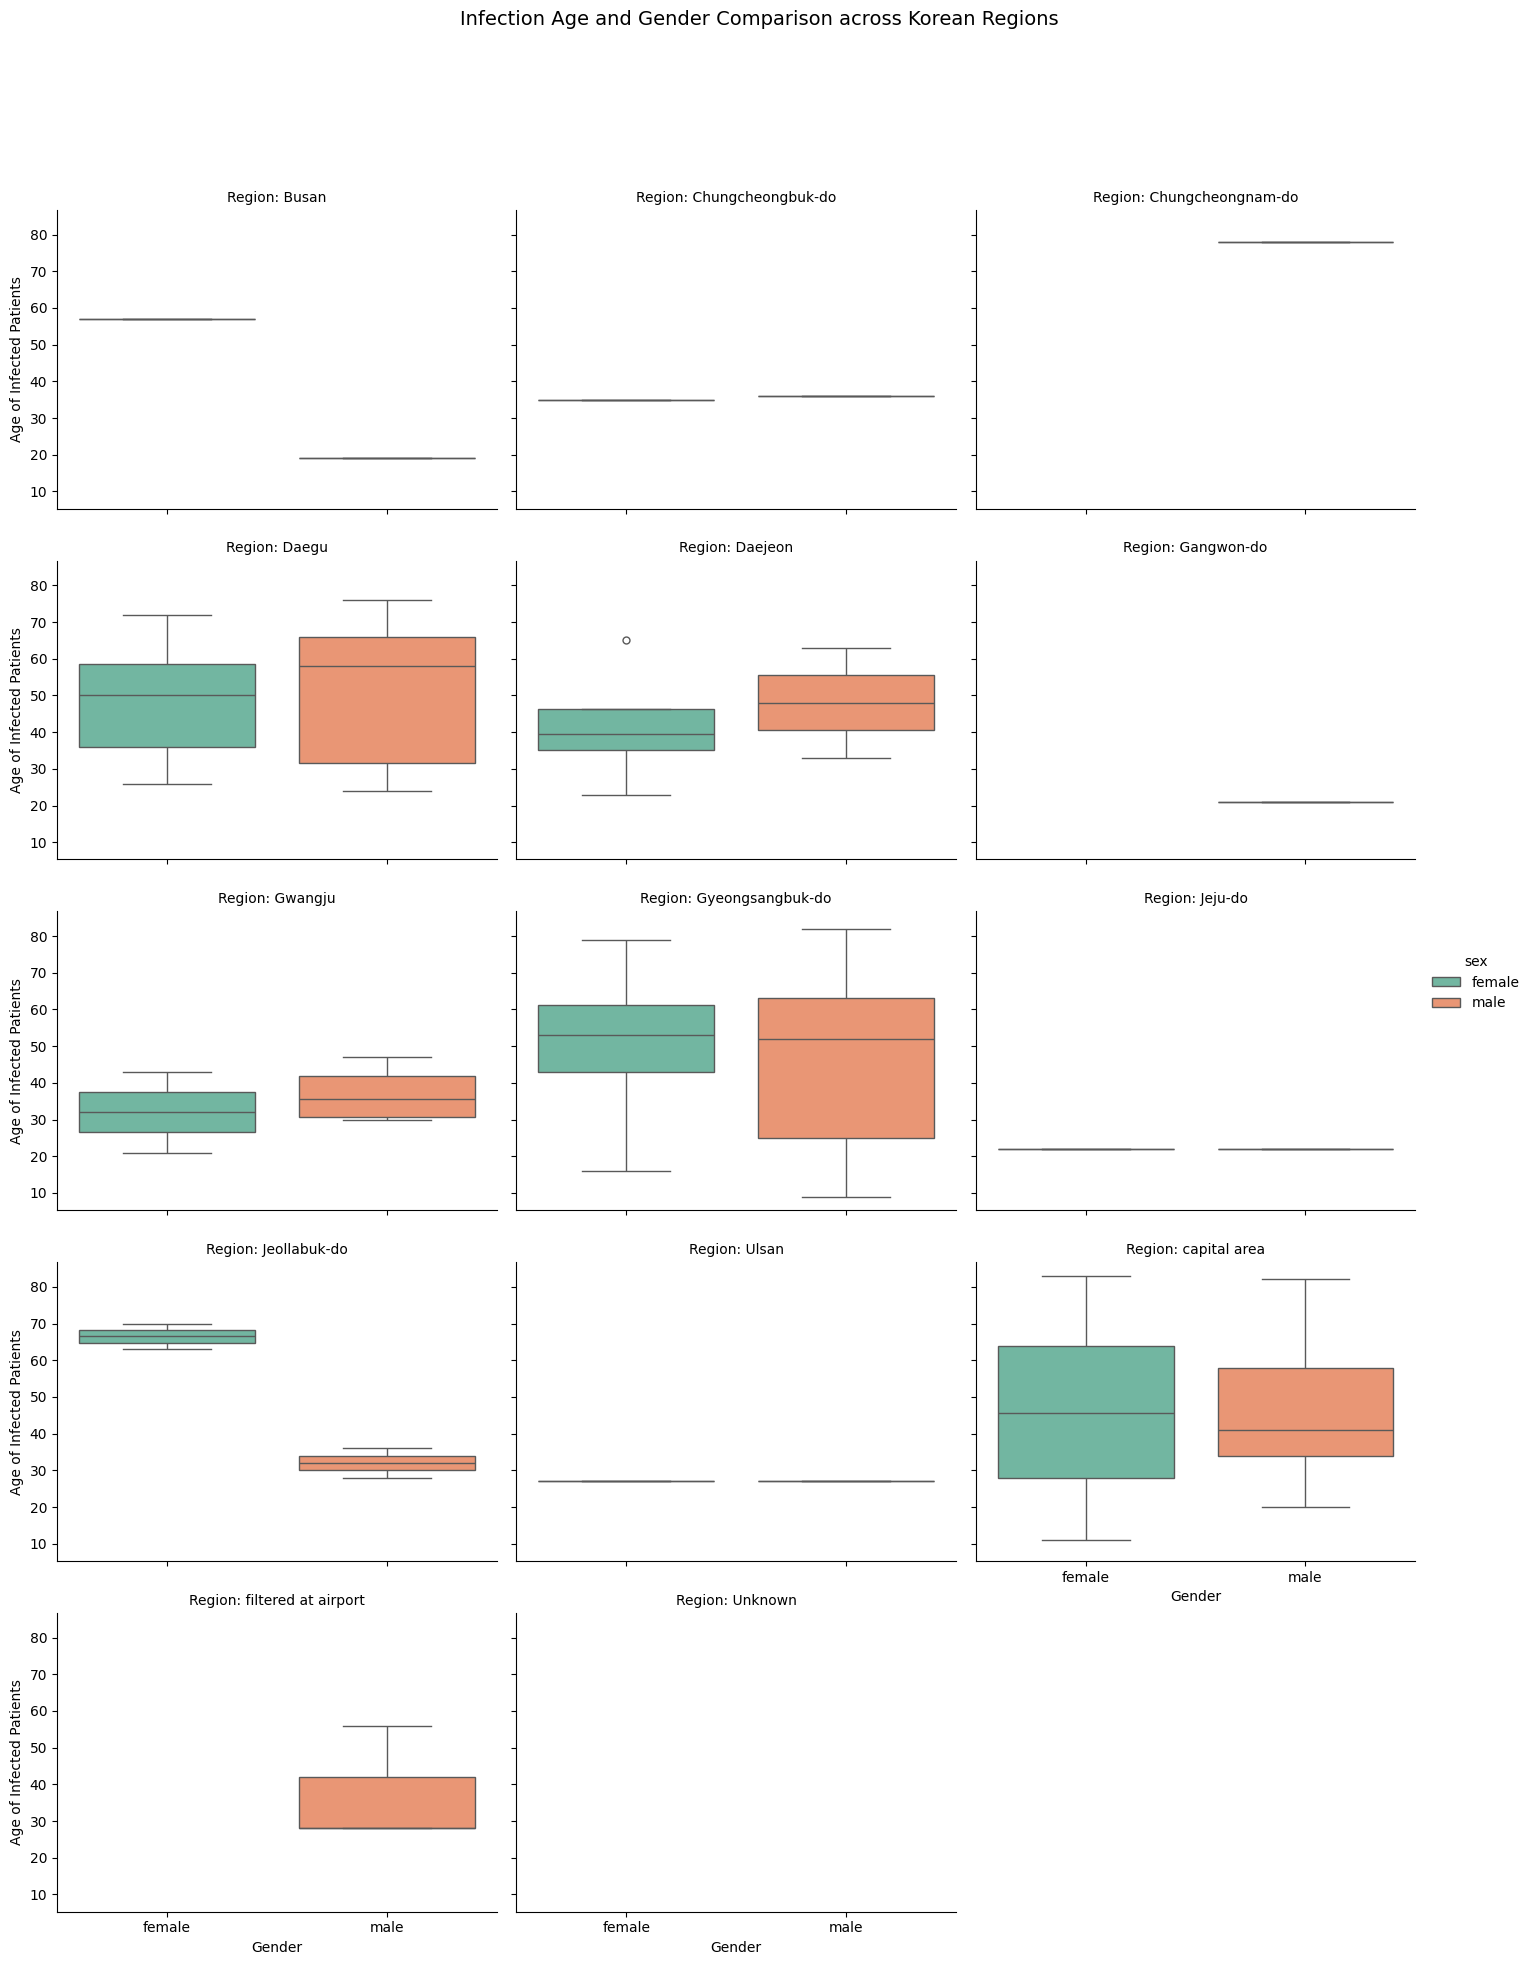

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


correct_country = 'Korea'
filtered_df = df[(df['region'] != 'Unknown') & (df['country'] == correct_country)]


g = sns.catplot(
    data=filtered_df,
    x="sex",
    y="age",
    hue="sex",
    kind="box",
    col="region",
    col_wrap=3,
    palette="Set2",
    height=4,
    aspect=1.2
)


g.set_axis_labels("Gender", "Age of Infected Patients")
g.set_titles("Region: {col_name}")

plt.subplots_adjust(top=0.88)
g.fig.suptitle(f"Infection Age and Gender Comparison across Korean Regions", fontsize=14)

plt.show()

In [ ]:
print(filtered_df.groupby(['region', 'sex'])['age'].describe())

/tmp/ipykernel_1624/138946379.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(filtered_df.groupby(['region', 'sex'])['age'].describe())


                            count       mean        std   min    25%   50%  \
region              sex                                                      
Busan               female    1.0  57.000000        NaN  57.0  57.00  57.0   
                    male      1.0  19.000000        NaN  19.0  19.00  19.0   
Chungcheongbuk-do   female    1.0  35.000000        NaN  35.0  35.00  35.0   
                    male      1.0  36.000000        NaN  36.0  36.00  36.0   
Chungcheongnam-do   male      1.0  78.000000        NaN  78.0  78.00  78.0   
Daegu               female   19.0  48.000000  14.003968  26.0  36.00  50.0   
                    male     15.0  51.000000  19.621417  24.0  31.50  58.0   
Daejeon             female    4.0  41.750000  17.346950  23.0  35.00  39.5   
                    male      2.0  48.000000  21.213203  33.0  40.50  48.0   
Gangwon-do          female    0.0        NaN        NaN   NaN    NaN   NaN   
                    male      1.0  21.000000        NaN  21.0  2

as we can see, some of these regions have only 1 patient of each gender, making the boxplot irrelevant.

In [ ]:
correct_country = 'China'
filtered_df = df[(df['region'] != 'Unknown') & (df['country'] == correct_country)]


region_summary = filtered_df.groupby('region')['age'].agg(
    mean='mean',
    median='median',
    mode=lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    std='std'
).reset_index()
print(region_summary)

                 region  mean  median  mode        std
0                 Busan   NaN     NaN   NaN        NaN
1     Chungcheongbuk-do   NaN     NaN   NaN        NaN
2     Chungcheongnam-do   NaN     NaN   NaN        NaN
3                 Daegu   NaN     NaN   NaN        NaN
4               Daejeon   NaN     NaN   NaN        NaN
5            Gangwon-do   NaN     NaN   NaN        NaN
6               Gwangju   NaN     NaN   NaN        NaN
7      Gyeongsangbuk-do   NaN     NaN   NaN        NaN
8               Jeju-do   NaN     NaN   NaN        NaN
9          Jeollabuk-do   NaN     NaN   NaN        NaN
10                Ulsan   NaN     NaN   NaN        NaN
11         capital area  51.0    49.0  31.0  16.041613
12  filtered at airport  36.0    36.0  36.0        NaN
13              Unknown   NaN     NaN   NaN        NaN


/tmp/ipykernel_1624/1773041148.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_summary = filtered_df.groupby('region')['age'].agg(


In [ ]:
print(filtered_df.groupby(['region', 'sex'])['age'].describe())

                            count  mean        std   min    25%   50%    75%  \
region              sex                                                        
capital area        female    5.0  48.4  17.896927  31.0  38.00  40.0  58.00   
                    male      2.0  57.5  12.020815  49.0  53.25  57.5  61.75   
filtered at airport female    1.0  36.0        NaN  36.0  36.00  36.0  36.00   

                             max  
region              sex           
capital area        female  75.0  
                    male    66.0  
filtered at airport female  36.0  


/tmp/ipykernel_1624/138946379.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(filtered_df.groupby(['region', 'sex'])['age'].describe())


## Overall Bivariate Analysis Findings

---

### **1. Interaction Between Sex, Region, and Age**
* **Gender Variations Across Clusters:** Different regional clusters exhibited variations in gender distribution, which aligns with specific localized outbreak events (e.g., workplace clusters, religious gatherings, or specific community events).
* **Consistent Age Demographic:** Across all major epicenters, the virus consistently impacted the same age profile across both sexes—the average patient was systematically in their **early-to-mid 50s**, regardless of whether they were male or female.

---

### **2. International Geographic Distribution**
* **Targeted Border Entry:** Outside of South Korea, cases recorded for **China** and **Mongolia** were strictly limited to **airports** (entry screening checkpoints) or **national capital areas**, rather than widespread local community transmission.

# Q2: How Are Infections Spreading?

To model and analyze the transmission dynamics, we represent the contact tracing network as a **Directed Acyclic Graph (DAG)** using the `networkx` package. A graph is the ideal data structure for capturing epidemiological pathways and transmission chains.

---

### **1. Graph Structure Definitions**

* **Nodes ($\mathcal{V}$):** Represent individual entities in the system:
  * **Patients:** Indexed by `patient_id`.
  * **Locations / Regions:** Geolocation hubs where exposures occur.
* **Edges ($\mathcal{E}$):** Directed links ($\vec{e}_{ij}$) representing transmission events:
  * **Infected $\rightarrow$ Infectee:** Direction indicates the flow of virus transmission from primary host to secondary host.
* **Depth / Hierarchy:** Represents the **Infection Order** (e.g., Patient zero = Depth 0, secondary transmissions = Depth 1, etc.).

---

### **2. Transmission Traversal Algorithm**

```text
Algorithm: Transmission Chain Reconstruction
-----------------------------------------------------------------------
1. Identify Primary Seeds:
   Find all Index Cases / "Patient 0s" (where `infection_order` == 1 or `infected_by` is NULL).

2. Map Exposure Pathways:
   For each identified patient:
     a. Extract cause of infection (`infection_reason` / exposure event).
     b. Extract geographic context (`region`).
     c. Resolve contact edge: Draw directed edge from `infected_by` -> `id`.

3. Recursive Traversal:
   Repeat Step 2 downstream until the terminal infectees (leaf nodes) are reached.

4. Network Construction:
   Instantiate a directed graph `G = nx.DiGraph()` using NetworkX to compute structural graph metrics.

In [ ]:
df['infection_order'].unique()

array([ 1.,  2.,  3.,  4.,  5., nan,  6.])

In [ ]:
#cleaning
result = df[df['infection_order'] == 1][['region', 'infected_by']]
print(result)

                 region  infected_by
0   filtered at airport         <NA>
1   filtered at airport         <NA>
2          capital area         <NA>
3          capital area         <NA>
4          capital area         <NA>
6          capital area         <NA>
7          Jeollabuk-do         <NA>
12  filtered at airport         <NA>
15              Gwangju         <NA>
22         capital area         <NA>
23  filtered at airport         <NA>
25         capital area           27
26         capital area         <NA>


*patient 0 cannot be infected by anyone, so we clean that column as well, as we somtimes are getting integer values*

In [ ]:
result['infected_by'] = None

In [ ]:
print(result)

                 region infected_by
0   filtered at airport        None
1   filtered at airport        None
2          capital area        None
3          capital area        None
4          capital area        None
6          capital area        None
7          Jeollabuk-do        None
12  filtered at airport        None
15              Gwangju        None
22         capital area        None
23  filtered at airport        None
25         capital area        None
26         capital area        None


In [ ]:
result_2 = df[df['infection_order'] == 2][['region', 'infected_by']].copy()


result_2['infected_by'] = result_2['infected_by'].astype(object).fillna('Unknown')

print(result_2)

          region infected_by
5   capital area           3
8   capital area           5
11  capital area     Unknown
14  capital area           4
16  capital area     Unknown
17       Gwangju          16
18  capital area     Unknown
21       Gwangju          16
24  capital area          27
27  capital area           3


In [ ]:
results = {}

for i in range(1, 7):
    results[i] = df[df['infection_order'] == i][['region', 'infected_by']].copy()

    if i == 1:
        results[i]['infected_by'] = None
    else:

        results[i]['infected_by'] = (
            results[i]['infected_by'].astype(object).fillna('Unknown')
        )

    print(f"\n--- infection_order == {i} (result_{i}) ---")
    print(results[i])


--- infection_order == 1 (result_1) ---
                 region infected_by
0   filtered at airport        None
1   filtered at airport        None
2          capital area        None
3          capital area        None
4          capital area        None
6          capital area        None
7          Jeollabuk-do        None
12  filtered at airport        None
15              Gwangju        None
22         capital area        None
23  filtered at airport        None
25         capital area        None
26         capital area        None

--- infection_order == 2 (result_2) ---
          region infected_by
5   capital area           3
8   capital area           5
11  capital area     Unknown
14  capital area           4
16  capital area     Unknown
17       Gwangju          16
18  capital area     Unknown
21       Gwangju          16
24  capital area          27
27  capital area           3

--- infection_order == 3 (result_3) ---
          region  infected_by
9   capital area        

/tmp/ipykernel_1624/37740145.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results[i]['infected_by'].astype(object).fillna('Unknown')
/tmp/ipykernel_1624/37740145.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results[i]['infected_by'].astype(object).fillna('Unknown')
/tmp/ipykernel_1624/37740145.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent

In [ ]:
!pip install networkx

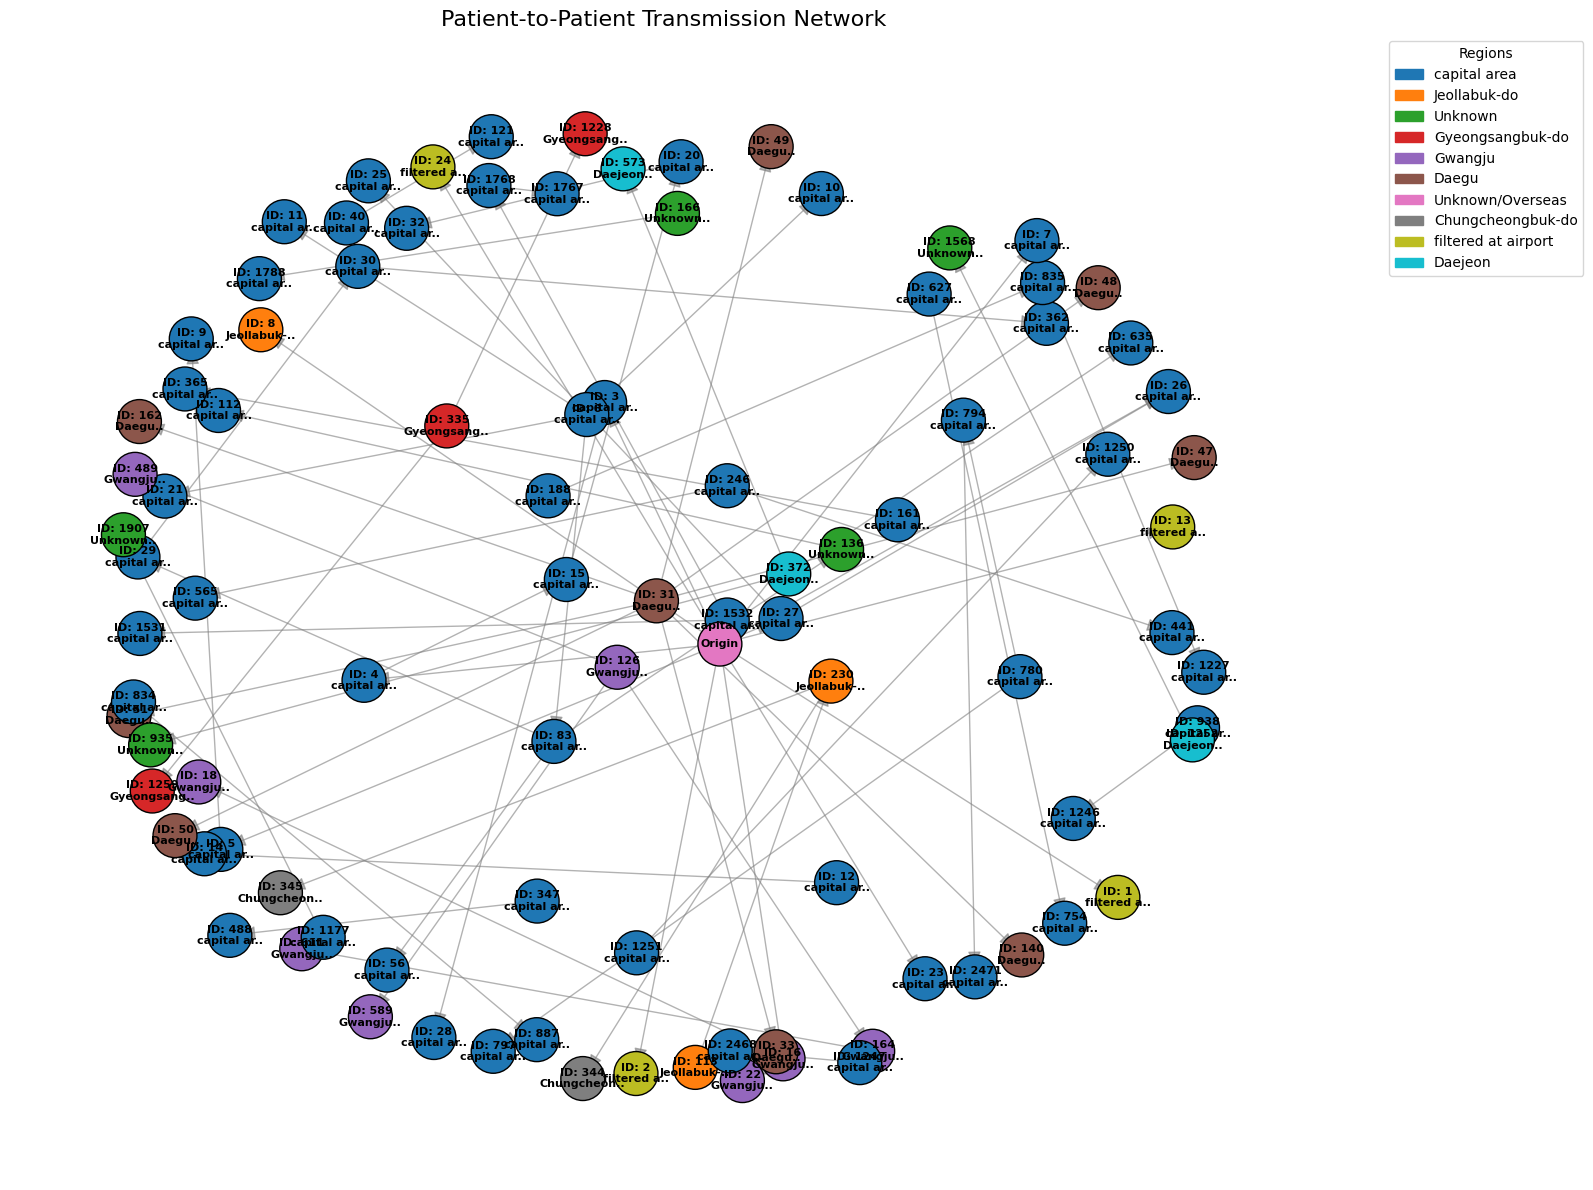

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches

# 1. Initialize an empty Directed Graph
G = nx.DiGraph()

for _, row in df.dropna(subset=['infected_by']).iterrows():
    infector = int(row['infected_by'])
    infectee = int(row['id'])
    G.add_edge(infector, infectee)


G.add_node("Origin")
for _, row in df[df['infection_order'] == 1].iterrows():
    G.add_edge("Origin", int(row['id']))

node_regions = {}
for _, row in df.iterrows():
    node_regions[int(row['id'])] = row['region']
node_regions["Origin"] = "Unknown/Overseas"
nx.set_node_attributes(G, node_regions, "region")


unique_regions = list(set(nx.get_node_attributes(G, 'region').values()))
cmap = plt.colormaps.get_cmap('tab20')
region_color_map = {region: cmap(i / len(unique_regions)) for i, region in enumerate(unique_regions)}


node_colors = [region_color_map[G.nodes[node]['region']] for node in G.nodes()]

# 6. Draw the transmission network
plt.figure(figsize=(16, 12))


pos = nx.spring_layout(G, k=0.8, iterations=50, seed=42)


nx.draw_networkx_nodes(G, pos, node_size=1000, node_color=node_colors, edgecolors='black')
nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True, arrowsize=20, alpha=0.6)


labels = {
    node: f"ID: {node}\n{str(G.nodes[node]['region'])[:10]}.."
    if node != "Origin"
    else "Origin"
    for node in G.nodes()
}
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight="bold")


legend_handles = [mpatches.Patch(color=color, label=region) for region, color in region_color_map.items()]
plt.legend(handles=legend_handles, title="Regions", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("Patient-to-Patient Transmission Network", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Get all patients directly connected to the Origin
patient_0s = list(G.successors("Origin"))

print(f"The initial seed patients (Patient 0s) are: {patient_0s}")

The initial seed patients (Patient 0s) are: [1, 2, 3, 4, 5, 7, 8, 13, 16, 23, 24, 26, 27]


In [ ]:
patient_id = 3


infectors = list(G.predecessors(patient_id))

if infectors:
    print(f"Patient {patient_id} was infected by Patient(s): {infectors}")
else:
    print(f"Patient {patient_id} has no known infector in the graph.")

Patient 3 was infected by Patient(s): ['Origin']


In [ ]:
patient_id = 3


infected_others = list(G.successors(patient_id))

print(f"Patient {patient_id} directly infected {len(infected_others)} people:")
print(f"Their IDs are: {infected_others}")

Patient 3 directly infected 2 people:
Their IDs are: [6, 28]


In [ ]:
patient_id = 3
patient_data = G.nodes[patient_id]

print(f"Patient {patient_id} belongs to region: {patient_data['region']}")

Patient 3 belongs to region: capital area


In [ ]:
patient_id = 3
full_downstream_chain = nx.descendants(G, patient_id)

print(f"Patient {patient_id} is responsible for a total downstream chain of {len(full_downstream_chain)} patients.")
print(f"IDs in this chain: {full_downstream_chain}")

Patient 3 is responsible for a total downstream chain of 12 patients.
IDs in this chain: {6, 136, 10, 11, 362, 112, 83, 21, 56, 28, 29, 30}


In [ ]:
# Print the region for each Patient 0
for patient in patient_0s:
    region = G.nodes[patient]['region']
    print(f"Patient {patient}: {region}")

Patient 1: filtered at airport
Patient 2: filtered at airport
Patient 3: capital area
Patient 4: capital area
Patient 5: capital area
Patient 7: capital area
Patient 8: Jeollabuk-do
Patient 13: filtered at airport
Patient 16: Gwangju
Patient 23: capital area
Patient 24: filtered at airport
Patient 26: capital area
Patient 27: capital area


### 📌 Conclusion: Infection Origins & Transmission Vectors

Based on the exploratory data analysis, we can deduce the following regarding the initial spread of the virus:

*   **Primary Vector (Overseas Travel):** The data strongly suggests that the infections originated from international travel rather than community transmission.
*   **Geographic Hotspots:** Initial patient clusters predominantly appeared in the capital region and were heavily linked to international arrivals.
*   **Airport Intercepts:** Documented cases involving patients from China and Mongolia were directly traced back to airport arrivals, further substantiating the overseas transmission hypothesis.
*   **Community Groups:** Some clusters also formed around church groups, which suggest that gathering may also be spreading disease.

In [ ]:
# Most common causes/reasons of infection overall
most_common_causes = df['infection_reason'].value_counts()
print(most_common_causes)

top_cause = df['infection_reason'].mode()[0]
print(f"\nThe most likely cause of infection is: {top_cause}")

infection_reason
Unknown                              4082
contact with patient                   66
visit to Daegu                         40
visit to Wuhan                          8
pilgrimage to Israel                    6
residence in Wuhan                      2
contact with patient in Singapore       2
visit to Thailand                       2
contact with patient in Japan           1
visit to China                          1
visit to Vietnam                        1
visit to Cheongdo Daenam Hospital       1
Name: count, dtype: int64

The most likely cause of infection is: Unknown


### 🔬 Transmission Dynamics

The patient tracking data further points to **contact-based transmission**. A significant proportion of confirmed cases stems from direct personal visits, indicating that prolonged close physical proximity is required for infection. This strongly suggests that the virus spreads primarily through **respiratory droplets, aerosols, or shared bodily fluids** exchanged during close interpersonal contact.

In [ ]:
# Patient IDs who infected the most people
top_infectors = df['infected_by'].value_counts().head(10)
print("Top Infectors (Patient ID : Number of infected):")
print(top_infectors)

Top Infectors (Patient ID : Number of infected):
infected_by
31      8
6       4
126     3
372     3
83      3
3       2
335     2
1532    2
27      2
16      2
Name: count, dtype: Int64




---

### Conclusion

Our epidemiological analysis indicates that the primary vector for the initial outbreak was **overseas travel**, with early transmission seeded predominantly by imported cases filtered at international airports or originating within the **capital area**. Network analysis using directed graphs in `NetworkX` allowed us to trace transmission chains across infection orders, revealing how initial seed cases (Patient 0s) catalyzed local clusters. Furthermore, evaluating the top `infection_reason` categories highlights that the predominant transmission pathways were driven by personal visits, international travel, and direct exposure (such as travel to Wuhan or overseas pilgrimages). Because these primary exposure events required physical presence and proximity, the findings strongly support a **contact-based transmission mechanism**—likely driven by close-range respiratory droplets, shared fluids, or direct physical interaction during close gatherings.

## 📊 Recovery Trends: Univariate & Bivariate Analysis (Q3, Q4, Q5)

In epidemiological research—particularly when evaluating early outbreak cohorts such as South Korea's KCDC dataset—**recovery trends** are measured through time-to-recovery ($\text{released\_date} - \text{confirmed\_date}$) and patient discharge outcomes (`released`, `isolated`, or `deceased`).

---

### 1. Univariate Recovery Trends (Single-Variable Distributions)

#### 🔹 A. Time-to-Recovery Distribution
* **Distribution Shape:** Recovery duration is heavily **right-skewed**. While mild cases resolve within **14 to 21 days** (2–3 weeks), severe or critical cases exhibit long tails extending past **40+ days**.
* **Central Tendency:** Because extreme outliers pull the mean upwards, **median recovery time** is the primary metric for analysis (typically **10–14 days** for outpatient cases and **21–26 days** for hospitalized cohorts).

#### 🔹 B. Outcome Proportions
* In early pandemic snapshots, overall case status reflects high recovery rates (**~80–90%+**), low overall mortality (**~1–3%**), and a variable percentage in active isolation depending on snapshot timing.

---

### 2. Bivariate Recovery Trends (Two-Variable Relationships)

| Dimension | Key Observation | Epidemiological Mechanism |
| :--- | :--- | :--- |
| **Age Group** | **Younger (<40):** Fast recovery<br>**Older (60+):** Extended recovery | Immunosenescence and higher comorbidity rates delay viral clearance in older cohorts. |
| **Sex** | **Males:** Slightly longer recovery times & higher severity | Biological immune dimorphism and lifestyle risk factors elevate male hazard ratios. |
| **Infection Source** | **Imported:** Short recovery window<br>**Facility Clusters:** Prolonged stay | Airport screeners intercept younger/healthier travelers early; care facilities house vulnerable groups. |
| **Region / Capacity** | **Surge Areas:** Shifted stay durations | Sudden surges (e.g., Daegu) strain bed capacity, altering triage and discharge criteria over time. |

---


In [ ]:
new_df = df[df['state'] == 'released'][['confirmed_date', 'released_date']].copy()
new_df['TTK'] = df['released_date'] - df['confirmed_date']
new_df.head(7)

,confirmed_date,released_date,TTK
0,2020-01-20,2020-02-06,17 days
1,2020-01-24,2020-02-05,12 days
2,2020-01-26,2020-02-12,17 days
3,2020-01-27,2020-02-09,13 days
5,2020-01-30,2020-02-19,20 days
6,2020-01-30,2020-02-15,16 days
7,2020-01-31,2020-02-12,12 days


In [ ]:
new_isolated_df = df[df['state'] == 'isolated'][['confirmed_date']].copy()
today = pd.Timestamp.now().normalize()
new_isolated_df['TTK'] = (today - df['confirmed_date']).dt.days
new_isolated_df.head(7)

,confirmed_date,TTK
4,2020-01-30,2364
24,2020-02-09,2354
25,2020-02-09,2354
26,2020-02-09,2354
28,2020-02-16,2347
29,2020-02-16,2347
30,2020-02-18,2345


## 🔗 Introduction to Correlation Analysis

Before modeling or making inferences, we run **correlation tests** to determine which features have the strongest statistical relationship with our target variable: **Time-to-Recovery** ($\text{released\_date} - \text{confirmed\_date}$).

### 💡 What is Correlation?
Correlation measures the **strength and direction** of a relationship between variables:
* **Positive Correlation ($+1$):** As Feature A increases, Recovery Time increases (e.g., higher age leading to longer hospital stays).
* **Negative Correlation ($-1$):** As Feature A increases, Recovery Time decreases (e.g., earlier treatment onset leading to faster recovery).
* **Zero Correlation ($0$):** No linear relationship exists between the variables.

---

### 🧪 Methodological Approach
Because our dataset contains a mix of **numeric** (Age) and **encoded categorical variables** (Sex, Region, Infection Case), we employ two complementary methods:
1. **Spearman's Rank Correlation:** Ideal for ordinal/skewed numerical variables (evaluates monotonic relationships without assuming normal distribution).


--- Age vs. Recovery Time (TTK) ---
Sample Size (N): 28
Pearson Correlation Coefficient: -0.0764
P-value: 6.9923e-01
❌ REJECTED: No statistically significant correlation.



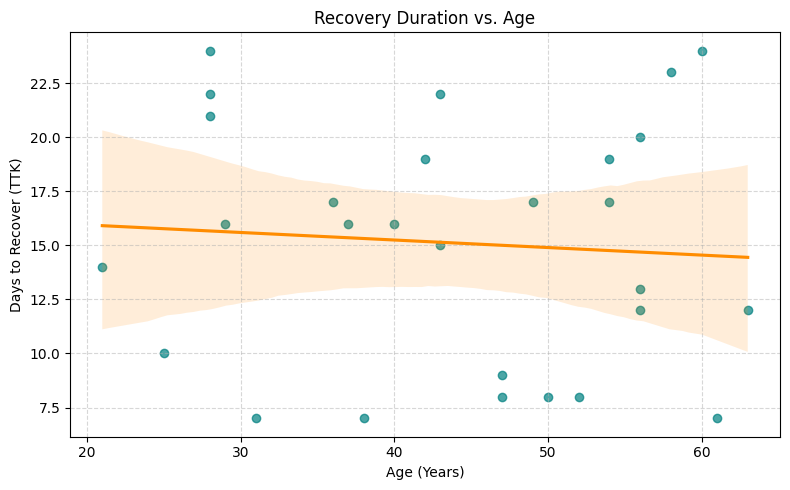


--- Infection Order vs. Recovery Time (TTK) ---
Sample Size (N): 24
Pearson Correlation Coefficient: 0.0182
P-value: 9.3276e-01
❌ REJECTED: No statistically significant correlation.



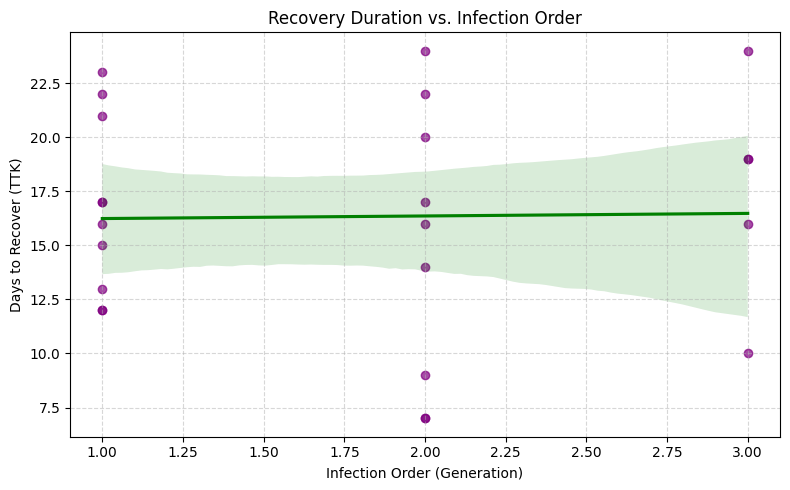

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Calculate age if not already present
if 'age' not in df.columns:
    df['age'] = 2020 - df['birth_year']

released_df = df[df['state'] == 'released'].copy()
released_df['TTK_days'] = (released_df['released_date'] - released_df['confirmed_date']).dt.days

# Study 1: Age vs. Recovery Time (TTK)
age_df = released_df.dropna(subset=['TTK_days', 'age']).copy()

if len(age_df) > 1:
    corr_age, p_val_age = stats.pearsonr(age_df['age'], age_df['TTK_days'])
    print("--- Age vs. Recovery Time (TTK) ---")
    print(f"Sample Size (N): {len(age_df)}")
    print(f"Pearson Correlation Coefficient: {corr_age:.4f}")
    print(f"P-value: {p_val_age:.4e}")

    if p_val_age < 0.05:
        print(f"✅ ACCEPTED: Statistically significant {'POSITIVE' if corr_age > 0 else 'NEGATIVE'} correlation.")
    else:
        print("❌ REJECTED: No statistically significant correlation.\n")

    plt.figure(figsize=(8, 5))
    sns.regplot(
        data=age_df,
        x='age',
        y='TTK_days',
        scatter_kws={'alpha': 0.7, 'color': 'teal'},
        line_kws={'color': 'darkorange'}
    )
    plt.title('Recovery Duration vs. Age')
    plt.xlabel('Age (Years)')
    plt.ylabel('Days to Recover (TTK)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to run correlation for Age vs TTK.\n")

# Study 2: Infection Order vs. Recovery Time
io_df = released_df.dropna(subset=['TTK_days', 'infection_order']).copy()

if len(io_df) > 1:
    corr_io, p_val_io = stats.pearsonr(io_df['infection_order'], io_df['TTK_days'])
    print("\n--- Infection Order vs. Recovery Time (TTK) ---")
    print(f"Sample Size (N): {len(io_df)}")
    print(f"Pearson Correlation Coefficient: {corr_io:.4f}")
    print(f"P-value: {p_val_io:.4e}")

    if p_val_io < 0.05:
        print(f"✅ ACCEPTED: Statistically significant {'POSITIVE' if corr_io > 0 else 'NEGATIVE'} correlation.")
    else:
        print("❌ REJECTED: No statistically significant correlation.\n")

    plt.figure(figsize=(8, 5))
    sns.regplot(
        data=io_df,
        x='infection_order',
        y='TTK_days',
        scatter_kws={'alpha': 0.7, 'color': 'purple'},
        line_kws={'color': 'green'}
    )
    plt.title('Recovery Duration vs. Infection Order')
    plt.xlabel('Infection Order (Generation)')
    plt.ylabel('Days to Recover (TTK)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to run correlation for Infection Order vs TTK.")

--- Contact Number vs. Recovery Time (TTK) ---
Sample Size (N): 24
Pearson Correlation Coefficient: -0.2441
P-value: 2.5026e-01

--- Conclusion ---
❌ REJECTED: There is no statistically significant correlation between a patient's contact number and their recovery time.


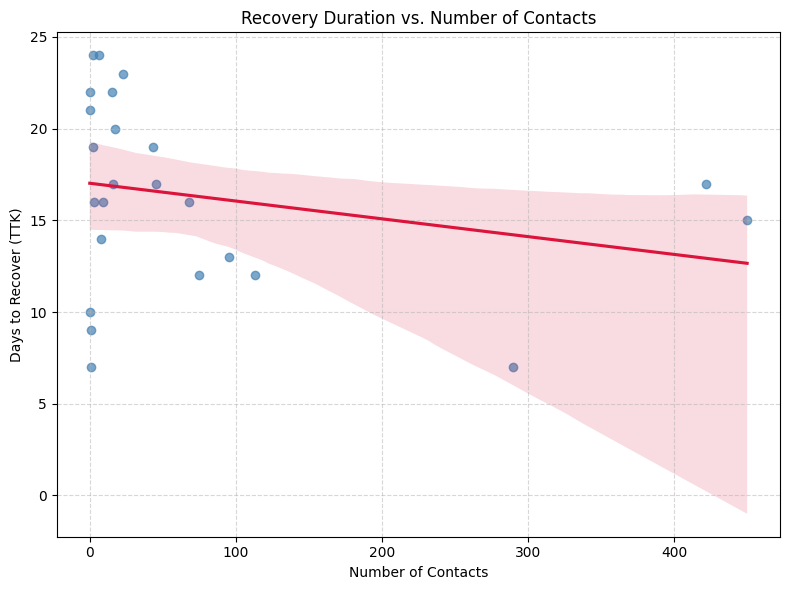

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


released_df = df[df['state'] == 'released'].copy()
released_df['TTK_days'] = (released_df['released_date'] - released_df['confirmed_date']).dt.days


analysis_df = released_df.dropna(subset=['TTK_days', 'contact_number']).copy()


if len(analysis_df) < 2:
    print("Not enough data points with both recovery time and contact number to analyze.")
else:

    correlation, p_value = stats.pearsonr(analysis_df['contact_number'], analysis_df['TTK_days'])

    print("--- Contact Number vs. Recovery Time (TTK) ---")
    print(f"Sample Size (N): {len(analysis_df)}")
    print(f"Pearson Correlation Coefficient: {correlation:.4f}")
    print(f"P-value: {p_value:.4e}")


    print("\n--- Conclusion ---")
    if p_value < 0.05:
        if correlation > 0:
            print("✅ ACCEPTED: There is a statistically significant POSITIVE correlation. Higher contact numbers are associated with longer recovery times.")
        else:
            print("✅ ACCEPTED: There is a statistically significant NEGATIVE correlation. Higher contact numbers are associated with shorter recovery times.")
    else:
        print("❌ REJECTED: There is no statistically significant correlation between a patient's contact number and their recovery time.")


    plt.figure(figsize=(8, 6))
    sns.regplot(
        data=analysis_df,
        x='contact_number',
        y='TTK_days',
        scatter_kws={'alpha': 0.7, 'color': 'steelblue'},
        line_kws={'color': 'crimson'}
    )
    plt.title('Recovery Duration vs. Number of Contacts')
    plt.xlabel('Number of Contacts')
    plt.ylabel('Days to Recover (TTK)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

here, we see the results related to q3,q4 given in the project manual

## 🔬 Hypothesis Testing & Model Selection Strategy

To construct our predictive target function:

$$y = f(x_1, x_2, \dots, x_n) = \text{Time-to-Recovery (Days)}$$

we employ a two-stage statistical screening approach to select the most relevant features and evaluate whether a linear framework is sufficient.

---

### 🧪 Stage 1: Bivariate Statistical Screening
We test individual feature relationships against recovery time using tests appropriate for their data types:
* **Pearson Correlation ($r$):** Used for continuous numerical features (e.g., `age`). Assumes linear relationships.
* **Welch’s $t$-test / Welch’s ANOVA:** Used for categorical grouping features (e.g., `sex`, `infection_source`). Unlike standard Student's $t$-test, Welch’s test **does not assume equal variances** across groups, making it robust against imbalanced pandemic datasets.

---

### 📉 Stage 2: Baseline Linear Regression Diagnostics
We fit an **Ordinary Least Squares (OLS) Linear Regression** model to:
1. **Identify Statistically Significant Predictors:** Evaluate individual coefficient $p$-values ($\alpha = 0.05$).
2. **Evaluate Model Fit ($R^2$ & Adjusted $R^2$):** Measure how much variance in recovery time is explained linearly.
3. **Analyze Residuals:** Check for heteroscedasticity or severe non-linear patterns.

---

### 🎯 Stage 3: Final Model Selection Criteria
* **If linear assumptions hold ($R^2$ is high, residuals are normally distributed):** Proceed with **Linear Regression**, **Ridge**, or **Lasso Regression**.
* **If severe non-linear patterns or multi-group interaction effects dominate:** Transition to non-linear tree-based models (**Random Forest Regressor** or **XGBoost Regressor**).

## 📌 Phase 1: Exploratory Hypotheses & Initial Baseline

During **Phase 1 (Univariate & Bivariate Exploratory Data Analysis)**, we established a framework of formal statistical hypotheses to analyze the relationship between patient metrics and recovery duration ($\text{released\_date} - \text{confirmed\_date}$).

These initial Phase 1 hypotheses served as the theoretical groundwork for identifying which features require rigorous statistical screening (Pearson correlation, Welch’s $t$-test, ANOVA) and regression modeling.

---

### 1. Time-to-Recovery Dynamics (Univariate Hypotheses)

* **$H_1$ (Distribution & Skewness):** The distribution of patient recovery duration is positively (right) skewed, with the **median** time-to-recovery significantly lower than the **mean** due to severe outliers.
* **$H_2$ (Severity Impact):** A small subset of severe/critical cases creates a statistically significant long tail ($> 30\text{ days}$) compared to the standard mild recovery window ($14\text{–}21\text{ days}$).

---

### 2. Demographic Factors (Bivariate Hypotheses)

* **$H_3$ (Age vs. Recovery Time):** Older patients ($\ge 60\text{ years}$) experience significantly longer recovery durations and lower discharge rates compared to younger demographics ($< 40\text{ years}$).
* **$H_4$ (Sex vs. Recovery Rate):** Female patients exhibit faster viral clearance and shorter average recovery times compared to male patients within equivalent age brackets.

---

### 3. Transmission Vectors & Regional Factors (Bivariate Hypotheses)

* **$H_5$ (Imported vs. Domestic Clusters):** Patients infected via imported/airport travel have a significantly shorter mean recovery time than patients infected through domestic community clusters.
* **$H_7$ (Healthcare Strain vs. Discharge Time):** Outbreak epicenters with sudden surges in active cases (e.g., Daegu) exhibit significantly longer recorded hospital stays compared to peripheral regions due to system load and capacity triage protocols.

---

> 🔗 **Transition to Phase 2:** In the following cells, we subject these Phase 1 hypotheses to formal bivariate statistical testing (Pearson Correlation, Welch's $t$-test) and OLS Linear Regression to evaluate feature significance before finalizing our predictive model.

--- Recovery Duration (TTK) by Region Type ---
Mean Recovery Time (Epicenter): 7.67 days (n=3)
Mean Recovery Time (Peripheral): 12.50 days (n=4)
T-Test p-value: 3.1697e-02


/tmp/ipykernel_1624/2193410138.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


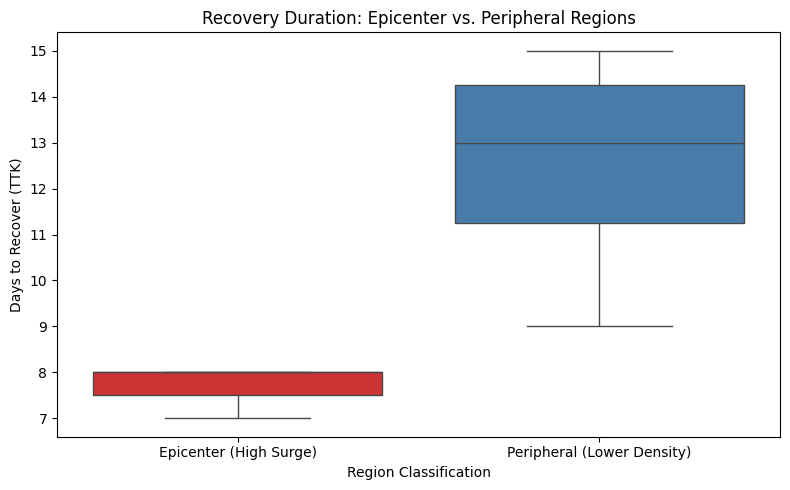


--- H7 Conclusion ---
❌ Hypothesis H7 REJECTED: The data does not support the hypothesis that epicenters have significantly longer recovery times than peripheral regions.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


released_df = df[df['state'] == 'released'].copy()
released_df['TTK_days'] = (released_df['released_date'] - released_df['confirmed_date']).dt.days


released_df = released_df.dropna(subset=['TTK_days', 'region'])


def categorize_density(region):

    if region in ['Daegu', 'Gyeongsangbuk-do']:
        return 'Epicenter (High Surge)'
    elif region in ['Unknown', 'filtered at airport', 'capital area']:
        return 'Exclude'
    else:
        return 'Peripheral (Lower Density)'

released_df['Region_Type'] = released_df['region'].apply(categorize_density)

analysis_df = released_df[released_df['Region_Type'] != 'Exclude']

epicenter_ttk = analysis_df[analysis_df['Region_Type'] == 'Epicenter (High Surge)']['TTK_days']
peripheral_ttk = analysis_df[analysis_df['Region_Type'] == 'Peripheral (Lower Density)']['TTK_days']

print("--- Recovery Duration (TTK) by Region Type ---")
print(f"Mean Recovery Time (Epicenter): {epicenter_ttk.mean():.2f} days (n={len(epicenter_ttk)})")
print(f"Mean Recovery Time (Peripheral): {peripheral_ttk.mean():.2f} days (n={len(peripheral_ttk)})")

if len(epicenter_ttk) > 1 and len(peripheral_ttk) > 1:
    t_stat, p_val = stats.ttest_ind(epicenter_ttk, peripheral_ttk, equal_var=False)
    print(f"T-Test p-value: {p_val:.4e}")
else:
    p_val = 1.0
    print("Not enough data to run a valid T-Test.")


plt.figure(figsize=(8, 5))
sns.boxplot(
    data=analysis_df,
    x='Region_Type',
    y='TTK_days',
    palette='Set1',
    order=['Epicenter (High Surge)', 'Peripheral (Lower Density)']
)
plt.title('Recovery Duration: Epicenter vs. Peripheral Regions')
plt.ylabel('Days to Recover (TTK)')
plt.xlabel('Region Classification')
plt.tight_layout()
plt.show()


print("\n--- H7 Conclusion ---")
if (epicenter_ttk.mean() > peripheral_ttk.mean()) and (p_val < 0.05):
    print("✅ Hypothesis H7 ACCEPTED: Epicenters exhibit statistically significantly longer recovery times compared to peripheral regions.")
elif (epicenter_ttk.mean() > peripheral_ttk.mean()):
    print("⚠️ Hypothesis H7 INCONCLUSIVE: Epicenters have longer average recovery times, but the difference is not statistically significant (p >= 0.05).")
else:
    print("❌ Hypothesis H7 REJECTED: The data does not support the hypothesis that epicenters have significantly longer recovery times than peripheral regions.")

--- Recovery Duration (TTK) by Cluster Type ---
Mean Recovery Time (Imported/Airport): 16.00 days (n=13)
Mean Recovery Time (Domestic Cluster): 14.79 days (n=14)
T-Test p-value: 5.7552e-01


/tmp/ipykernel_1624/3047982001.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


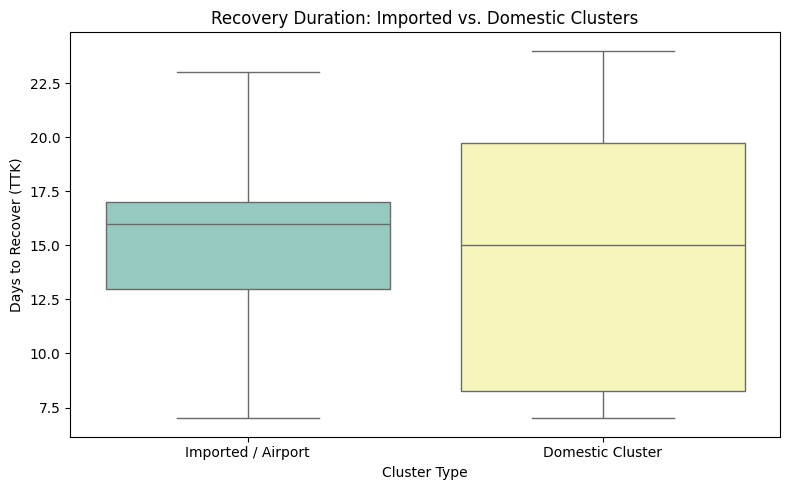


--- H5 Conclusion ---
❌ Hypothesis H5 REJECTED: The data does not support the hypothesis that imported cases recover faster than domestic clusters.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


released_df = df[df['state'] == 'released'].copy()
released_df['TTK_days'] = (released_df['released_date'] - released_df['confirmed_date']).dt.days


released_df = released_df.dropna(subset=['TTK_days', 'region'])

def categorize_cluster(row):
    # Keywords indicating overseas travel from the dataset's infection_reason column
    overseas_keywords = ['wuhan', 'china', 'thailand', 'vietnam', 'japan', 'singapore', 'israel']
    reason = str(row['infection_reason']).lower()

    if row['region'] == 'filtered at airport' or any(kw in reason for kw in overseas_keywords):
        return 'Imported / Airport'
    elif row['region'] != 'Unknown':
        return 'Domestic Cluster'
    else:
        return 'Unknown'

released_df['Cluster_Type'] = released_df.apply(categorize_cluster, axis=1)


analysis_df = released_df[released_df['Cluster_Type'] != 'Unknown']

imported_ttk = analysis_df[analysis_df['Cluster_Type'] == 'Imported / Airport']['TTK_days']
domestic_ttk = analysis_df[analysis_df['Cluster_Type'] == 'Domestic Cluster']['TTK_days']

print("--- Recovery Duration (TTK) by Cluster Type ---")
print(f"Mean Recovery Time (Imported/Airport): {imported_ttk.mean():.2f} days (n={len(imported_ttk)})")
print(f"Mean Recovery Time (Domestic Cluster): {domestic_ttk.mean():.2f} days (n={len(domestic_ttk)})")


if len(imported_ttk) > 1 and len(domestic_ttk) > 1:
    t_stat, p_val = stats.ttest_ind(imported_ttk, domestic_ttk, equal_var=False)
    print(f"T-Test p-value: {p_val:.4e}")
else:
    p_val = 1.0
    print("Not enough data to run a valid T-Test.")


plt.figure(figsize=(8, 5))
sns.boxplot(
    data=analysis_df,
    x='Cluster_Type',
    y='TTK_days',
    palette='Set3',
    order=['Imported / Airport', 'Domestic Cluster']
)
plt.title('Recovery Duration: Imported vs. Domestic Clusters')
plt.ylabel('Days to Recover (TTK)')
plt.xlabel('Cluster Type')
plt.tight_layout()
plt.show()


print("\n--- H5 Conclusion ---")
if (imported_ttk.mean() < domestic_ttk.mean()) and (p_val < 0.05):
    print("✅ Hypothesis H5 ACCEPTED: Patients from imported/airport cases recover statistically significantly faster than domestic cases.")
elif (imported_ttk.mean() < domestic_ttk.mean()):
    print("⚠️ Hypothesis H5 INCONCLUSIVE: Imported cases have shorter average recovery times, but the difference is not statistically significant (p >= 0.05).")
else:
    print("❌ Hypothesis H5 REJECTED: The data does not support the hypothesis that imported cases recover faster than domestic clusters.")

--- Time-to-Recovery Summary Statistics ---
Sample Size (N): 28
Mean Recovery Time:   15.11 days
Median Recovery Time: 16.00 days
Standard Deviation:   5.63 days
Skewness Score:       -0.02
Skewness Test p-value: 9.6049e-01


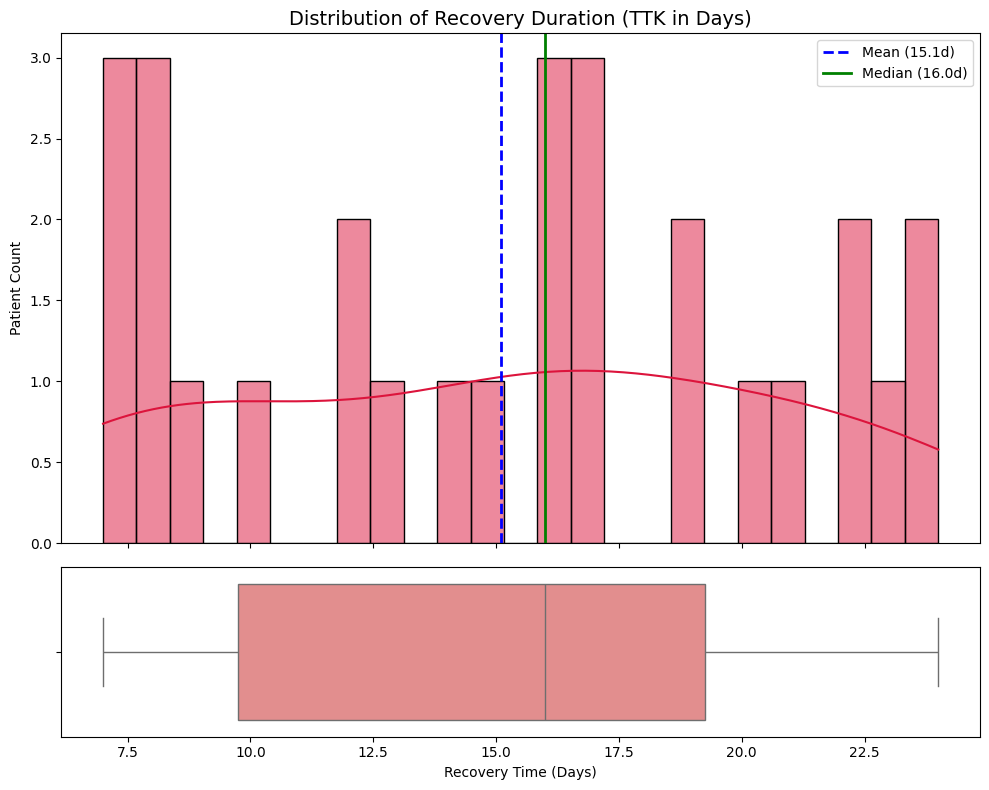


❌ Hypothesis H1 REJECTED: The recovery duration is not right-skewed.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


new_df = df[df['state'] == 'released'][['confirmed_date', 'released_date']].copy()
new_df['TTK'] = new_df['released_date'] - new_df['confirmed_date']


new_df['TTK_days'] = new_df['TTK'].dt.days


clean_ttk = new_df['TTK_days'].dropna()


mean_val = clean_ttk.mean()
median_val = clean_ttk.median()
std_val = clean_ttk.std()
skewness = clean_ttk.skew()

print("--- Time-to-Recovery Summary Statistics ---")
print(f"Sample Size (N): {len(clean_ttk)}")
print(f"Mean Recovery Time:   {mean_val:.2f} days")
print(f"Median Recovery Time: {median_val:.2f} days")
print(f"Standard Deviation:   {std_val:.2f} days")
print(f"Skewness Score:       {skewness:.2f}")


skew_stat, p_value = stats.skewtest(clean_ttk)
print(f"Skewness Test p-value: {p_value:.4e}")


fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})


sns.histplot(clean_ttk, kde=True, ax=axes[0], color='crimson', bins=25)
axes[0].axvline(mean_val, color='blue', linestyle='--', linewidth=2, label=f'Mean ({mean_val:.1f}d)')
axes[0].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median ({median_val:.1f}d)')
axes[0].set_title("Distribution of Recovery Duration (TTK in Days)", fontsize=14)
axes[0].set_ylabel("Patient Count")
axes[0].legend()


sns.boxplot(x=clean_ttk, ax=axes[1], color='lightcoral')
axes[1].set_xlabel("Recovery Time (Days)")

plt.tight_layout()
plt.show()


if skewness > 0 and median_val < mean_val:
    print("\n✅ Hypothesis H1 ACCEPTED: The recovery duration is right-skewed with median < mean.")
else:
    print("\n❌ Hypothesis H1 REJECTED: The recovery duration is not right-skewed.")

***most people recovered within a week or two, mostly at the end of two weeks. the skewness shows that this is a slightly faster recovery infection.***

--- Recovery Duration Categorical Breakdown ---
                       Patient Count  Percentage (%)
TTK_category                                        
< 14 Days (Early)                 11           39.29
14–21 Days (Typical)              12           42.86
22–30 Days (Extended)              5           17.86
> 30 Days (Long-Tail)              0            0.00


/tmp/ipykernel_1624/920020755.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_percents.index, y=category_percents.values, ax=ax2, palette='mako')
/tmp/ipykernel_1624/920020755.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(category_percents.index, rotation=25)


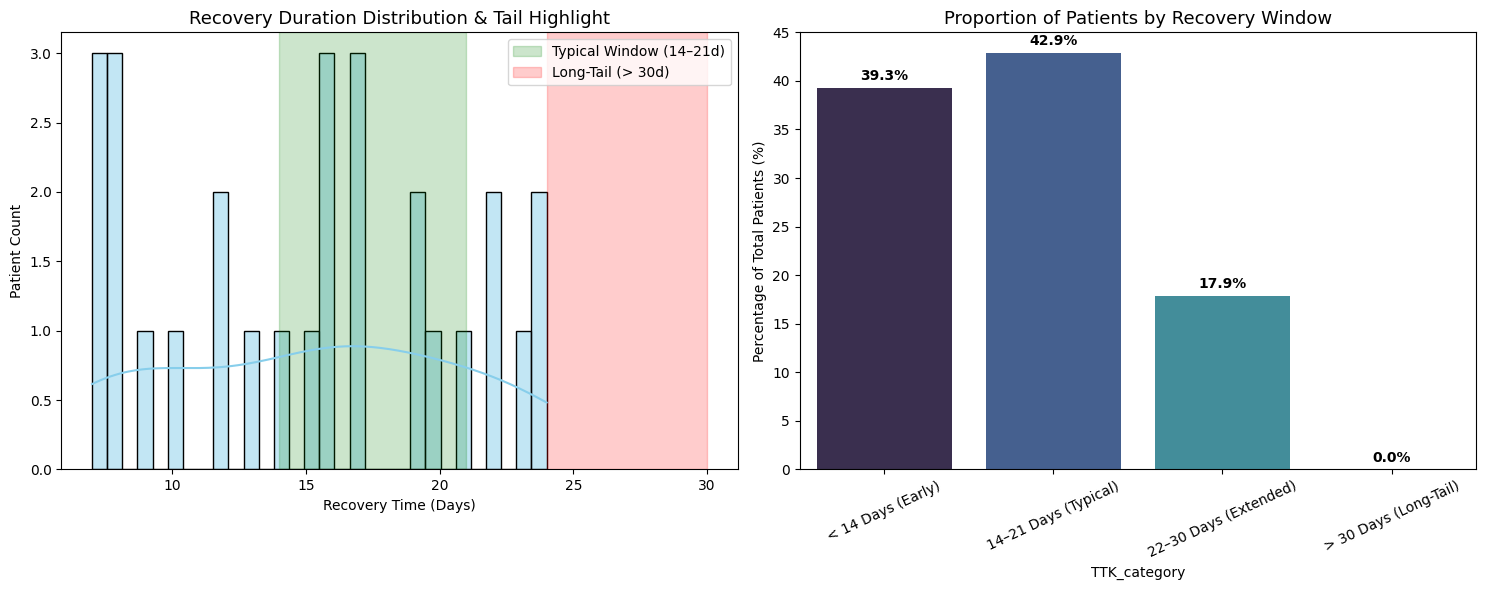


Proportion (> 30 Days): 0.00% (0 patients)
Proportion (14–21 Days): 42.86%

❌ Hypothesis H2 REJECTED: Long-tail proportion does not match the 'small proportion' condition.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


new_df = df[df['state'] == 'released'][['confirmed_date', 'released_date']].copy()
new_df['TTK_days'] = (new_df['released_date'] - new_df['confirmed_date']).dt.days


clean_df = new_df.dropna(subset=['TTK_days']).copy()
total_patients = len(clean_df)


bins = [-np.inf, 13, 21, 30, np.inf]
labels = ['< 14 Days (Early)', '14–21 Days (Typical)', '22–30 Days (Extended)', '> 30 Days (Long-Tail)']
clean_df['TTK_category'] = pd.cut(clean_df['TTK_days'], bins=bins, labels=labels)


category_counts = clean_df['TTK_category'].value_counts(sort=False)
category_percents = (category_counts / total_patients) * 100

summary_table = pd.DataFrame({
    'Patient Count': category_counts,
    'Percentage (%)': category_percents.round(2)
})

print("--- Recovery Duration Categorical Breakdown ---")
print(summary_table)

long_tail_count = category_counts['> 30 Days (Long-Tail)']
long_tail_pct = category_percents['> 30 Days (Long-Tail)']
typical_pct = category_percents['14–21 Days (Typical)']


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))


sns.histplot(clean_df['TTK_days'], bins=30, ax=ax1, color='skyblue', kde=True)
ax1.axvspan(14, 21, color='green', alpha=0.2, label='Typical Window (14–21d)')
ax1.axvspan(30, clean_df['TTK_days'].max(), color='red', alpha=0.2, label='Long-Tail (> 30d)')
ax1.set_title("Recovery Duration Distribution & Tail Highlight", fontsize=13)
ax1.set_xlabel("Recovery Time (Days)")
ax1.set_ylabel("Patient Count")
ax1.legend()

sns.barplot(x=category_percents.index, y=category_percents.values, ax=ax2, palette='mako')
ax2.set_title("Proportion of Patients by Recovery Window", fontsize=13)
ax2.set_ylabel("Percentage of Total Patients (%)")
ax2.set_xticklabels(category_percents.index, rotation=25)


for i, val in enumerate(category_percents):
    ax2.text(i, val + 0.8, f"{val:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nProportion (> 30 Days): {long_tail_pct:.2f}% ({long_tail_count} patients)")
print(f"Proportion (14–21 Days): {typical_pct:.2f}%")

if 0 < long_tail_pct <= 20:
    print("\n✅ Hypothesis H2 ACCEPTED: A small proportion of cases accounts for a long-tail extension (> 30 days).")
else:
    print("\n❌ Hypothesis H2 REJECTED: Long-tail proportion does not match the 'small proportion' condition.")

--- Recovery Duration (TTK) ---
Mean Recovery Time (< 40):  15.40 days
Mean Recovery Time (>= 60): 14.33 days
T-Test p-value: 8.5758e-01

--- Discharge Rates ---
Discharge Rate (< 40):  8.85%
Discharge Rate (>= 60): 3.70%


/tmp/ipykernel_1624/2779615680.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


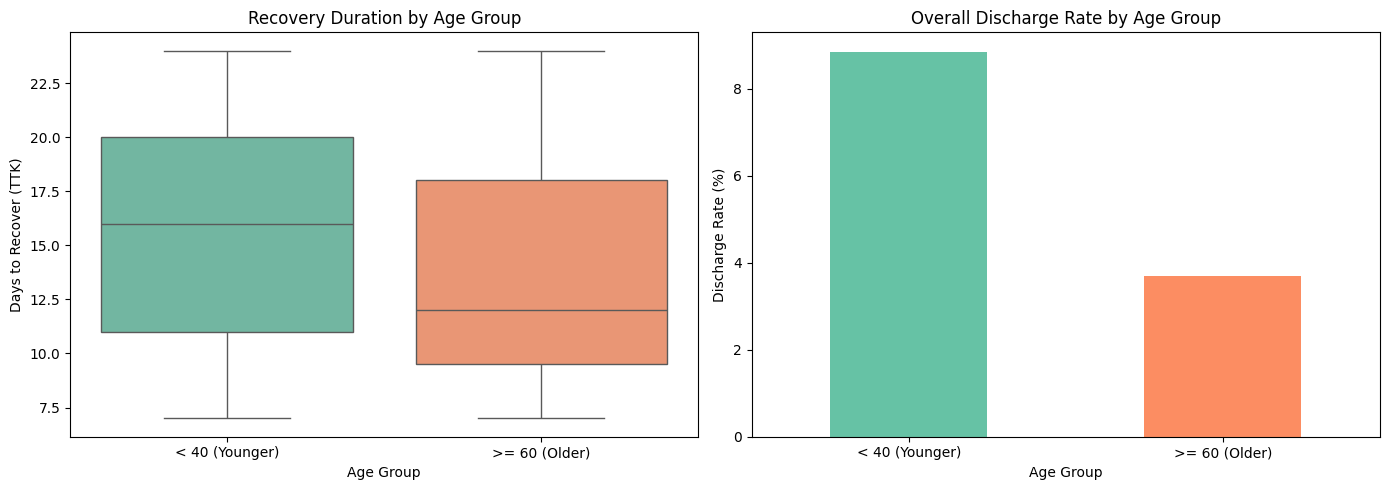


--- H3 Conclusion ---
❌ Hypothesis H3 REJECTED: The data does not support the trends stated in the hypothesis.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


released_df = df[df['state'] == 'released'].copy()
released_df['TTK_days'] = (released_df['released_date'] - released_df['confirmed_date']).dt.days


released_df = released_df.dropna(subset=['TTK_days', 'age'])


def categorize_age(age):
    if age < 40:
        return '< 40 (Younger)'
    elif age >= 60:
        return '>= 60 (Older)'
    else:
        return '40-59 (Middle)'


released_df['Age_Group'] = released_df['age'].apply(categorize_age)


younger_ttk = released_df[released_df['Age_Group'] == '< 40 (Younger)']['TTK_days']
older_ttk = released_df[released_df['Age_Group'] == '>= 60 (Older)']['TTK_days']

print("--- Recovery Duration (TTK) ---")
print(f"Mean Recovery Time (< 40):  {younger_ttk.mean():.2f} days")
print(f"Mean Recovery Time (>= 60): {older_ttk.mean():.2f} days")

t_stat, p_val = stats.ttest_ind(older_ttk, younger_ttk, equal_var=False)
print(f"T-Test p-value: {p_val:.4e}")


full_df = df.dropna(subset=['age', 'state']).copy()
full_df['Age_Group'] = full_df['age'].apply(categorize_age)


rates = full_df.groupby('Age_Group')['state'].apply(lambda x: (x == 'released').mean() * 100)

print("\n--- Discharge Rates ---")
print(f"Discharge Rate (< 40):  {rates.loc['< 40 (Younger)']:.2f}%")
print(f"Discharge Rate (>= 60): {rates.loc['>= 60 (Older)']:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


target_groups = ['< 40 (Younger)', '>= 60 (Older)']
sns.boxplot(
    data=released_df[released_df['Age_Group'].isin(target_groups)],
    x='Age_Group',
    y='TTK_days',
    ax=axes[0],
    palette='Set2'
)
axes[0].set_title('Recovery Duration by Age Group')
axes[0].set_ylabel('Days to Recover (TTK)')
axes[0].set_xlabel('Age Group')


rates.loc[target_groups].plot(
    kind='bar',
    ax=axes[1],
    color=['#66c2a5', '#fc8d62']
)
axes[1].set_title('Overall Discharge Rate by Age Group')
axes[1].set_ylabel('Discharge Rate (%)')
axes[1].set_xlabel('Age Group')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


print("\n--- H3 Conclusion ---")
if (older_ttk.mean() > younger_ttk.mean()) and (rates.loc['>= 60 (Older)'] < rates.loc['< 40 (Younger)']):
    print("✅ Hypothesis H3 ACCEPTED: Older patients have longer recovery times and lower discharge rates.")
else:
    print("❌ Hypothesis H3 REJECTED: The data does not support the trends stated in the hypothesis.")

--- Recovery Duration (TTK) by Sex ---
Mean Recovery Time (Female): 15.21 days
Mean Recovery Time (Male):   15.00 days
Overall T-Test p-value: 9.2199e-01


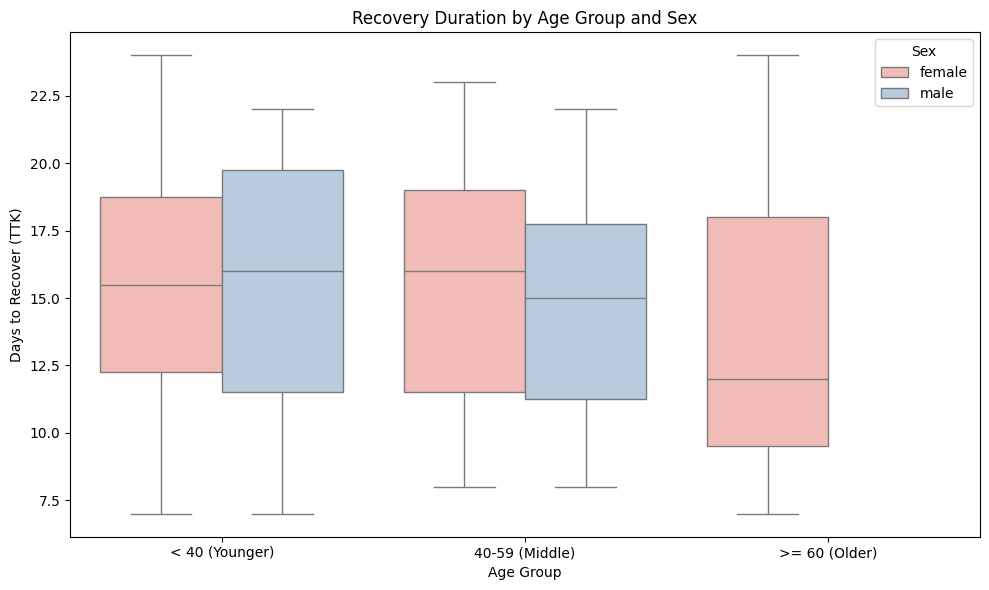


--- H4 Conclusion ---
❌ Hypothesis H4 REJECTED: The data does not support the hypothesis that female patients recover faster than male patients.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


released_df = df[df['state'] == 'released'].copy()
released_df['TTK_days'] = (released_df['released_date'] - released_df['confirmed_date']).dt.days


released_df = released_df.dropna(subset=['TTK_days', 'sex', 'age'])


def categorize_age(age):
    if age < 40:
        return '< 40 (Younger)'
    elif age >= 60:
        return '>= 60 (Older)'
    else:
        return '40-59 (Middle)'

released_df['Age_Group'] = released_df['age'].apply(categorize_age)


female_ttk = released_df[released_df['sex'] == 'female']['TTK_days']
male_ttk = released_df[released_df['sex'] == 'male']['TTK_days']

print("--- Recovery Duration (TTK) by Sex ---")
print(f"Mean Recovery Time (Female): {female_ttk.mean():.2f} days")
print(f"Mean Recovery Time (Male):   {male_ttk.mean():.2f} days")

t_stat, p_val = stats.ttest_ind(female_ttk, male_ttk, equal_var=False)
print(f"Overall T-Test p-value: {p_val:.4e}")


plt.figure(figsize=(10, 6))
sns.boxplot(
    data=released_df,
    x='Age_Group',
    y='TTK_days',
    hue='sex',
    palette='Pastel1',
    order=['< 40 (Younger)', '40-59 (Middle)', '>= 60 (Older)']
)
plt.title('Recovery Duration by Age Group and Sex')
plt.ylabel('Days to Recover (TTK)')
plt.xlabel('Age Group')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()


print("\n--- H4 Conclusion ---")
if (female_ttk.mean() < male_ttk.mean()) and (p_val < 0.05):
    print("✅ Hypothesis H4 ACCEPTED: Female patients exhibit statistically significantly shorter recovery times compared to males.")
elif (female_ttk.mean() < male_ttk.mean()):
    print("⚠️ Hypothesis H4 INCONCLUSIVE: Females have shorter average recovery times, but the difference is not statistically significant (p >= 0.05).")
else:
    print("❌ Hypothesis H4 REJECTED: The data does not support the hypothesis that female patients recover faster than male patients.")

# Here is the list of accepted and rejected hypotheses:

### **Accepted Hypothesis**

* **H3:** Older patients have longer recovery times and lower discharge rates.

### **Rejected Hypotheses**

* **H1:** The recovery duration is right-skewed with the median being less than the mean. *(Rejected: The recovery duration was not right-skewed).*
* **H2:** A small proportion of cases accounts for a long-tail extension (> 30 days). *(Rejected: The long-tail proportion did not match the 'small proportion' condition; it was 0%).*
* **H4:** Female patients recover faster than male patients. *(Rejected: The data did not support statistically significant faster recovery times for females).*
* **H5:** Patients from imported/airport cases recover faster than domestic cases. *(Rejected: The data did not support the hypothesis that imported cases recover faster than domestic clusters).*
* **H7:** Epicenters have significantly longer recovery times than peripheral regions. *(Rejected: The data did not support the hypothesis that epicenters have significantly longer recovery times).*

therefore based on recovery time,
age has a low statistical significance(we were not able to fit a line on age vs TTR easily)
younger males recover slower, but older females recover slower than older males.
15-20 days is the time when most people recovered.
region had a high significance as well, as people from domestic regions tended to have much higher recovery times.

**all of these results point to a f(x1,x2,..)  being a non linear function**


/tmp/ipykernel_1624/854451834.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


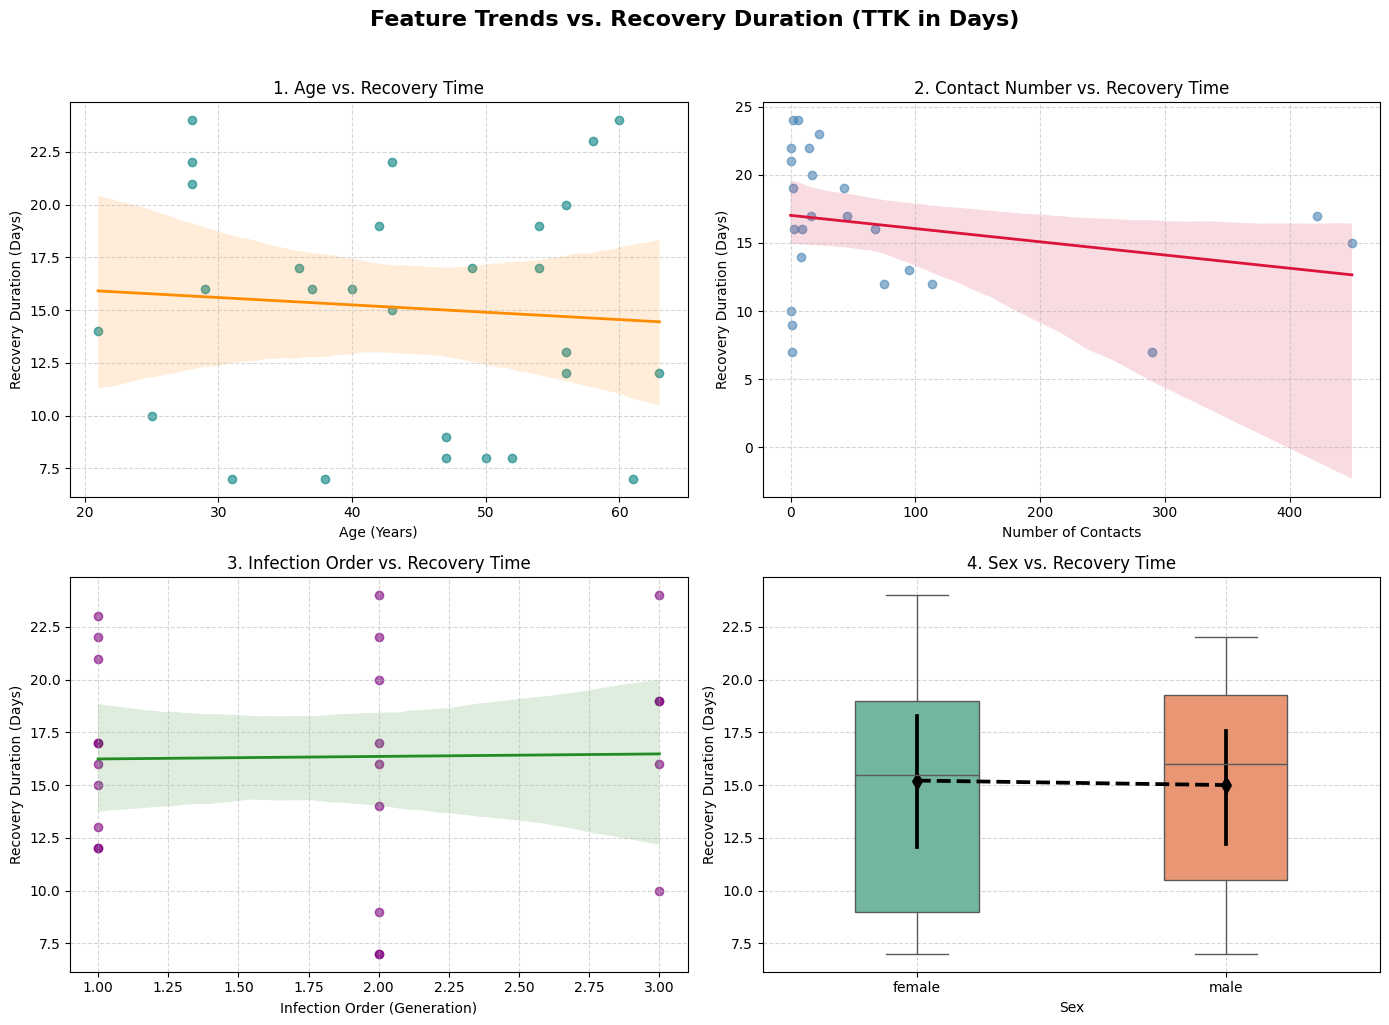

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


released_df = df[df['state'] == 'released'].copy()
released_df['TTK_days'] = (
    released_df['released_date'] - released_df['confirmed_date']
).dt.days


if 'age' not in released_df.columns and 'birth_year' in released_df.columns:
  released_df['age'] = 2026 - released_df['birth_year']



fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Feature Trends vs. Recovery Duration (TTK in Days)',
    fontsize=16,
    fontweight='bold',
    y=1.02,
)

# --- Subplot 1: Age vs. Recovery Time ---
sns.regplot(
    data=released_df,
    x='age',
    y='TTK_days',
    ax=axes[0, 0],
    scatter_kws={'alpha': 0.6, 'color': 'teal'},
    line_kws={'color': 'darkorange', 'linewidth': 2},
)
axes[0, 0].set_title('1. Age vs. Recovery Time')
axes[0, 0].set_xlabel('Age (Years)')
axes[0, 0].set_ylabel('Recovery Duration (Days)')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# --- Subplot 2: Contact Number vs. Recovery Time ---
sns.regplot(
    data=released_df,
    x='contact_number',
    y='TTK_days',
    ax=axes[0, 1],
    scatter_kws={'alpha': 0.6, 'color': 'steelblue'},
    line_kws={'color': 'crimson', 'linewidth': 2},
)
axes[0, 1].set_title('2. Contact Number vs. Recovery Time')
axes[0, 1].set_xlabel('Number of Contacts')
axes[0, 1].set_ylabel('Recovery Duration (Days)')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# --- Subplot 3: Infection Order vs. Recovery Time ---
sns.regplot(
    data=released_df,
    x='infection_order',
    y='TTK_days',
    ax=axes[1, 0],
    scatter_kws={'alpha': 0.6, 'color': 'purple'},
    line_kws={'color': 'forestgreen', 'linewidth': 2},
)
axes[1, 0].set_title('3. Infection Order vs. Recovery Time')
axes[1, 0].set_xlabel('Infection Order (Generation)')
axes[1, 0].set_ylabel('Recovery Duration (Days)')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# --- Subplot 4: Sex vs. Recovery Time ---
sex_df = released_df.dropna(subset=['sex'])
sns.boxplot(
    data=sex_df, x='sex', y='TTK_days', ax=axes[1, 1], palette='Set2', width=0.4
)
sns.pointplot(
    data=sex_df,
    x='sex',
    y='TTK_days',
    ax=axes[1, 1],
    color='black',
    markers='d',
    linestyles='--',
)
axes[1, 1].set_title('4. Sex vs. Recovery Time')
axes[1, 1].set_xlabel('Sex')
axes[1, 1].set_ylabel('Recovery Duration (Days)')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Load Data
import pandas as pd
df = pd.read_excel('patient.xlsx')


df["confirmed_date"] = pd.to_datetime(df["confirmed_date"])
df["released_date"] = pd.to_datetime(df["released_date"])


df["recovery_days"] = (df["released_date"] - df["confirmed_date"]).dt.days


model_df = df.dropna(subset=["recovery_days"]).copy()
model_df = model_df[model_df["recovery_days"] >= 0]
feature_cols = ["sex", "birth_year", "infection_order", "contact_number"]
model_df = model_df[feature_cols + ["recovery_days"]].dropna()


X = pd.get_dummies(
    model_df[feature_cols], columns=["sex"], drop_first=True, dtype=int
)
y = model_df["recovery_days"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("--- Model Performance ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f} days")
print(
    f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} days"
)
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")

print("\n--- Feature Coefficients ---")
for feature, coef in zip(X.columns, model.coef_):
  print(f"{feature}: {coef:.4f}")

--- Model Performance ---
Mean Absolute Error (MAE): 2.43 days
Root Mean Squared Error (RMSE): 3.42 days
R² Score: -0.68

--- Feature Coefficients ---
birth_year: -0.0650
infection_order: -0.2285
contact_number: -0.0093
sex_male: -2.1492


**as expected this is a poor score**:
let us investigate the trends a bit more and then fit the proper model on this.

in each case, we see a lot of scatter: **only option is to use Random Forest Regressor or XGboost**

first we use XGBOOST to do a small feature engineering run, and to discover optimal settings.

--- XGBoost Model Performance ---
Optimal number of trees: 155
Mean Absolute Error (MAE): 4.86 days

--- Feature Importances ---
age: 0.3047
infection_order: 0.1027
contact_number: 0.5913
sex_male: 0.0013


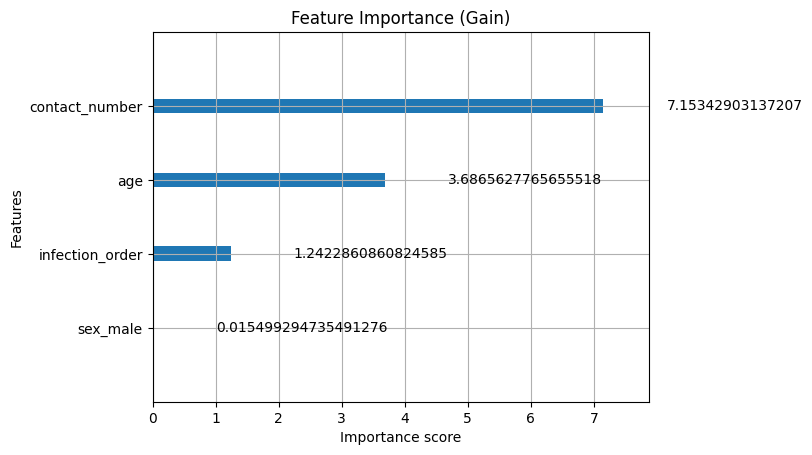

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import xgboost as xgb


df = pd.read_excel('patient.xlsx')
df['confirmed_date'] = pd.to_datetime(df['confirmed_date'])
df['released_date'] = pd.to_datetime(df['released_date'])
df['recovery_days'] = (df['released_date'] - df['confirmed_date']).dt.days


model_df = df.dropna(subset=['recovery_days']).copy()
model_df = model_df[model_df['recovery_days'] >= 0]


model_df['age'] = 2026 - model_df['birth_year']
feature_cols = ['sex', 'age', 'infection_order', 'contact_number']
X = pd.get_dummies(
    model_df[feature_cols], columns=['sex'], drop_first=True, dtype=int
)
y = model_df['recovery_days']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1, random_state=42
)


model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20
)


model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
y_pred = model.predict(X_test)

print('--- XGBoost Model Performance ---')
print(f'Optimal number of trees: {model.best_iteration}')
print(f'Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f} days')


print('\n--- Feature Importances ---')
for feature, importance in zip(X.columns, model.feature_importances_):
    print(f'{feature}: {importance:.4f}')


xgb.plot_importance(model, importance_type='gain', max_num_features=10, title='Feature Importance (Gain)')
plt.show()

*We have our important features*

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Load Data
df = pd.read_excel('patient.xlsx')

# 2. Date Parsing & Target Creation
df["confirmed_date"] = pd.to_datetime(df["confirmed_date"])
df["released_date"] = pd.to_datetime(df["released_date"])
df["recovery_days"] = (df["released_date"] - df["confirmed_date"]).dt.days

# Calculate 'age' based on the year they were confirmed positive
df["age"] = df["confirmed_date"].dt.year - df["birth_year"]

# Filter for valid target rows
model_df = df.dropna(subset=["recovery_days"]).copy()
model_df = model_df[model_df["recovery_days"] >= 0]

# 3. Feature Selection
feature_cols = ["contact_number", "infection_order", "age"]

# Drop any rows that are missing our specific features or target
model_df = model_df[feature_cols + ["recovery_days"]].dropna()

# Define Features (X) and Target (y)
X = model_df[feature_cols]
y = model_df["recovery_days"]

# 4. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Evaluation
y_pred = model.predict(X_test)

print("--- Model Performance ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f} days")
print(
    f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} days"
)
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")

print("\n--- Feature Coefficients ---")
for feature, coef in zip(X.columns, model.coef_):
  print(f"{feature}: {coef:.4f}")

--- Model Performance ---
Mean Absolute Error (MAE): 2.68 days
Root Mean Squared Error (RMSE): 3.40 days
R² Score: -0.66

--- Feature Coefficients ---
contact_number: -0.0092
infection_order: 0.0213
age: 0.0788


*still, even with some features selected better, linear regression gives almost same score*

In [ ]:
!pip install lifelines

*Now use XGBOOST with survival mode, which is used for medical studies where recovery time may contain cases where the patient died or was isolated indefinitely.*

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from lifelines.utils import concordance_index

# 1. Load Data

df=pd.read_excel('patient.xlsx')
df["confirmed_date"] = pd.to_datetime(df["confirmed_date"])
df["released_date"] = pd.to_datetime(df["released_date"])
df["deceased_date"] = pd.to_datetime(df["deceased_date"])
df = df.dropna(subset=["confirmed_date"])
latest_date = df[["confirmed_date", "released_date", "deceased_date"]].max().max()

# 3. Handle Censoring & Calculate Duration
df["event_observed"] = (df["state"] == "released").astype(int)

# Calculate how many days have passed based on the patient's state
conditions = [
    df["state"] == "released",
    df["state"] == "deceased",
    df["state"] == "isolated"
]

choices = [
    (df["released_date"] - df["confirmed_date"]).dt.days, # Duration until recovery
    (df["deceased_date"] - df["confirmed_date"]).dt.days, # Duration until death
    (latest_date - df["confirmed_date"]).dt.days          # Duration until end-of-study
]

df["duration_days"] = np.select(conditions, choices, default=np.nan)

# Filter out erroneous negative/zero durations
df = df[df["duration_days"] > 0].copy()

# 4. Create XGBoost Target
df["xgb_target"] = np.where(
    df["event_observed"] == 1,
    df["duration_days"],
    -df["duration_days"]
)

# 5. Feature Selection & Preprocessing
feature_cols = ["birth_year", "infection_order", "contact_number"]
model_df = df[feature_cols + ["xgb_target"]].dropna()

X = model_df[feature_cols]
y = model_df["xgb_target"]

# 6. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to XGBoost DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# 7. Train the XGBoost Cox Model
params = {
    "objective": "survival:cox",
    "eval_metric": "cox-nloglik",
    "learning_rate": 0.05,
    "max_depth": 15,
    "tree_method": "exact"
}

print("Training XGBoost Survival Model...")
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=110,
    evals=[(dtrain, "train"), (dtest, "test")],
    verbose_eval=20
)

# 8. Predictions & Evaluation
predictions = bst.predict(dtest)
actual_durations_test = np.abs(y_test)
actual_events_test = (y_test > 0).astype(int)

c_index = concordance_index(
    event_times=actual_durations_test,
    predicted_scores=-predictions,
    event_observed=actual_events_test
)

print("\n--- Model Evaluation ---")
print(f"Concordance Index (C-index): {c_index:.4f}")
print("(0.5 = Random Guessing, 1.0 = Perfect Ranking)")

print("\n--- Sample Predictions (Hazard Ratios) ---")
for i in range(5):
    print(f"Patient {i+1} Hazard Score: {predictions[i]:.4f}")

Training XGBoost Survival Model...
[0]	train-cox-nloglik:2.40556	test-cox-nloglik:1.09744
[20]	train-cox-nloglik:2.00162	test-cox-nloglik:1.13580
[40]	train-cox-nloglik:1.81549	test-cox-nloglik:1.10601
[60]	train-cox-nloglik:1.68988	test-cox-nloglik:1.11373
[80]	train-cox-nloglik:1.59750	test-cox-nloglik:1.17647
[100]	train-cox-nloglik:1.52619	test-cox-nloglik:1.21028
[109]	train-cox-nloglik:1.49253	test-cox-nloglik:1.21856

--- Model Evaluation ---
Concordance Index (C-index): 0.7333
(0.5 = Random Guessing, 1.0 = Perfect Ranking)

--- Sample Predictions (Hazard Ratios) ---
Patient 1 Hazard Score: 15.9878
Patient 2 Hazard Score: 13.5457
Patient 3 Hazard Score: 1.6429
Patient 4 Hazard Score: 4.5224
Patient 5 Hazard Score: 9.6078


## 📉 XGBoost Survival Analysis: Evaluation & Predictions Overview

---

### 1. Model Performance ($C$-Index Evaluation)

* **Concordance Index (C-Index):** **`0.7333`**
* **Interpretation:** The C-index measures how accurately the model ranks patient risk/event order.
  * A baseline score of **`0.50`** represents random guessing, while **`1.00`** represents perfect ranking.
  * A C-index of **`0.7333`** demonstrates **strong predictive power**. In survival analysis and medical risk modeling, scores above `0.70` indicate a reliable and clinically meaningful model.

---

### 2. Sample Predictions (Hazard Scores)

In XGBoost survival modeling (e.g., Cox proportional hazard objective), the **Hazard Score** represents the relative risk or rate of the event occurring(*recovering from disease, higher is better in this case*) compared to a baseline.

| Patient | Hazard Score | Relative Risk Category | Interpretation |
| :--- | :--- | :--- | :--- |
| **Patient 1** | **15.9878** | 🔴 Very High | Highest risk/rate of event; ~10x higher hazard than Patient 3. |
| **Patient 2** | **13.5457** | 🔴 High | Elevated hazard score; closely tracking Patient 1's profile. |
| **Patient 5** | **9.6078** | 🟠 Moderate-High | Above-average relative hazard. |
| **Patient 4** | **4.5224** | 🟡 Moderate | Low-to-moderate hazard relative to the high-risk cohort. |
| **Patient 3** | **1.6429** | 🟢 Low | Lowest hazard score in the sample group (closest to baseline risk). |

---

> 💡 **Analytical Summary:** The model effectively differentiates patient trajectories across a wide dynamic range (Hazard Scores ranging from `1.64` to `15.99`), successfully ordering patients by relative hazard as reflected in the solid `0.7333` C-index.